# 01 — ADME EDA (Part 1) - Biogen Dataset

**Goal**: Understand the ADME dataset thoroughly before making any cleaning or modelling decisions.  
**Dataset**: `data/raw/ADME_public_set_3521.csv` — 3521 compounds, 6 log-transformed ADME endpoints.  
**Outputs**: Findings documented in Section 1.10; no data modified here.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.eda import smiles_validity_report, missing_value_report, max_corr_report
from src.features import rdkit_descriptors
from src.plotting import endpoint_distributions

SEED = 42
DATA_PATH = '../data/raw/ADME_public_set_3521.csv'

TRAIN_MPNN2 = True        # set True to train MPNN2 (graph + rdkit_2d_normalized)
TRAIN_MPNN_GRAPH = True   # set True to train MPNN (graph-only, no rdkit descriptors)
TUNE_MPNN2 = True # set True to run grid search (~30-60 min)
RUN_RADIUS_SENSITIVITY = False  # set True to run 2.4b radius sweep (~2 min)

ENDPOINT_COLS = [
    'LOG HLM_CLint (mL/min/kg)',
    'LOG MDR1-MDCK ER (B-A/A-B)',
    'LOG SOLUBILITY PH 6.8 (ug/mL)',
    'LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound)',
    'LOG PLASMA PROTEIN BINDING (RAT) (% unbound)',
    'LOG RLM_CLint (mL/min/kg)',
]
EP_SHORT = ['HLM', 'MDR1', 'SOL', 'PPB_H', 'PPB_R', 'RLM']
EP_SHORT_MAP = dict(zip(ENDPOINT_COLS, EP_SHORT))

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## 1.1 — Load & Inspect

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nDtypes:')
print(df.dtypes)
df.head()

Shape: (3521, 10)

Columns: ['Internal ID', 'Vendor ID', 'SMILES', 'CollectionName', 'LOG HLM_CLint (mL/min/kg)', 'LOG MDR1-MDCK ER (B-A/A-B)', 'LOG SOLUBILITY PH 6.8 (ug/mL)', 'LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound)', 'LOG PLASMA PROTEIN BINDING (RAT) (% unbound)', 'LOG RLM_CLint (mL/min/kg)']

Dtypes:
Internal ID                                        object
Vendor ID                                          object
SMILES                                             object
CollectionName                                     object
LOG HLM_CLint (mL/min/kg)                         float64
LOG MDR1-MDCK ER (B-A/A-B)                        float64
LOG SOLUBILITY PH 6.8 (ug/mL)                     float64
LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound)    float64
LOG PLASMA PROTEIN BINDING (RAT) (% unbound)      float64
LOG RLM_CLint (mL/min/kg)                         float64
dtype: object


,Internal ID,Vendor ID,SMILES,CollectionName,LOG HLM_CLint (mL/min/kg),LOG MDR1-MDCK ER (B-A/A-B),LOG SOLUBILITY PH 6.8 (ug/mL),LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound),LOG PLASMA PROTEIN BINDING (RAT) (% unbound),LOG RLM_CLint (mL/min/kg)
0,Mol1,317714313,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,emolecules,0.6757,1.4932,0.0899,0.9912,0.5185,1.3922
1,Mol2,324056965,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,emolecules,0.6757,1.0408,0.5502,0.0997,0.2683,1.0279
2,Mol3,304005766,CN(c1ncc(F)cn1)[C@H]1CCCNC1,emolecules,0.6757,-0.3588,NaN,2.0000,2.0000,1.0279
3,Mol4,194963090,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,emolecules,0.6757,1.0267,1.6571,-1.1580,-1.4034,1.0279
4,Mol5,324059015,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,emolecules,0.9964,1.0106,NaN,1.0156,1.0923,1.6291


## 1.2 — SMILES Validity Report

Report only — no rows dropped here. Dropping is a cleaning decision made after EDA.

In [3]:
validity = smiles_validity_report(df, smiles_col='SMILES')
print(f"Valid SMILES  : {validity['valid_count']} ({validity['valid_count']/len(df)*100:.2f}%)")
print(f"Invalid SMILES: {validity['invalid_count']} ({validity['invalid_count']/len(df)*100:.2f}%)")
if validity['invalid_indices']:
    print(f"Invalid row indices: {validity['invalid_indices']}")
    print(df.loc[validity['invalid_indices'], ['Internal ID', 'SMILES']])
else:
    print('No invalid SMILES found.')

Valid SMILES  : 3521 (100.00%)
Invalid SMILES: 0 (0.00%)
No invalid SMILES found.


## 1.3 — Duplicate Check

In [4]:
from rdkit import Chem

# Duplicate raw SMILES strings
dup_raw = df['SMILES'].duplicated(keep=False)
print(f"Duplicate raw SMILES: {dup_raw.sum()} rows ({df['SMILES'].duplicated().sum()} extra copies)")

# Canonical SMILES duplicates (catches representation variants)
def to_canonical(smi):
    if pd.isna(smi):
        return None
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol is not None else None

df['canonical_smiles'] = df['SMILES'].apply(to_canonical)
dup_can = df['canonical_smiles'].duplicated(keep=False) & df['canonical_smiles'].notna()
n_dup_can = df['canonical_smiles'].duplicated().sum()
print(f"Duplicate canonical SMILES: {dup_can.sum()} rows ({n_dup_can} extra copies)")

if n_dup_can > 0:
    dup_df = df[dup_can].sort_values('canonical_smiles')
    # Check endpoint consistency among duplicates
    dup_ep_std = dup_df.groupby('canonical_smiles')[ENDPOINT_COLS].std()
    inconsistent = (dup_ep_std > 0).any(axis=1)
    print(f"Duplicates with inconsistent endpoint values: {inconsistent.sum()}")
    display(dup_df[['Internal ID', 'canonical_smiles'] + ENDPOINT_COLS].head(20))

Duplicate raw SMILES: 0 rows (0 extra copies)
Duplicate canonical SMILES: 0 rows (0 extra copies)


SMILES = string encoding of molecule
Canoncial SMILES = single, deterministic string generated via an algo (RDKit), always produces the same SMILES regardless of how molecule originally encoded.

Synthetic examples — SMILES → Canonical:


,Name,Input SMILES,Canonical SMILES,Changed?
0,Ethanol (reversed),OCC,CCO,✓
1,Aspirin (variant A),OC(=O)c1ccccc1OC(C)=O,CC(=O)Oc1ccccc1C(=O)O,✓
2,Aspirin (variant B),CC(=O)Oc1ccccc1C(O)=O,CC(=O)Oc1ccccc1C(=O)O,✓


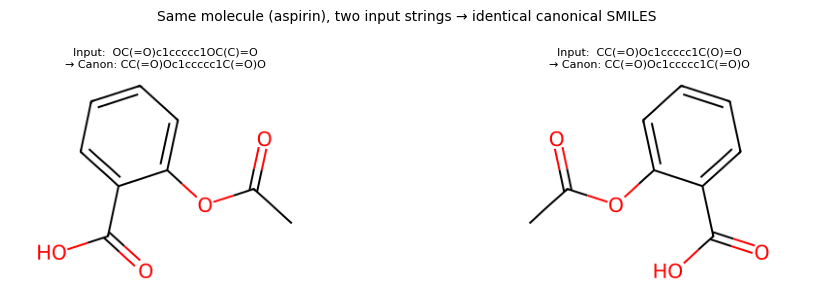


Dataset spot-check — first 5 compounds:


,Internal ID,SMILES,canonical_smiles,changed
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,False
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,False
2,Mol3,CN(c1ncc(F)cn1)[C@H]1CCCNC1,CN(c1ncc(F)cn1)[C@H]1CCCNC1,False
3,Mol4,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,False
4,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,False


In [5]:
from rdkit import Chem
from rdkit.Chem import Draw

# ── 1. Show the transformation on synthetic examples ──────────────────────────
non_canonical_examples = [
    ('Ethanol (reversed)', 'OCC'),
    ('Aspirin (variant A)',  'OC(=O)c1ccccc1OC(C)=O'),
    ('Aspirin (variant B)',  'CC(=O)Oc1ccccc1C(O)=O'),
]

rows = []
for name, smi in non_canonical_examples:
    mol = Chem.MolFromSmiles(smi)
    canon = Chem.MolToSmiles(mol)
    rows.append({'Name': name, 'Input SMILES': smi, 'Canonical SMILES': canon,
                 'Changed?': '✓' if smi != canon else '—'})

print("Synthetic examples — SMILES → Canonical:")
display(pd.DataFrame(rows))

# ── 2. Draw aspirin variants side-by-side to show same structure ──────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (name, smi) in zip(axes, non_canonical_examples[1:]):
    mol = Chem.MolFromSmiles(smi)
    canon = Chem.MolToSmiles(mol)
    img = Draw.MolToImage(mol, size=(320, 220))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Input:  {smi}\n→ Canon: {canon}', fontsize=8)
plt.suptitle('Same molecule (aspirin), two input strings → identical canonical SMILES', fontsize=10)
plt.tight_layout()
plt.show()

# ── 3. Verify our dataset: original vs canonical for first 5 compounds ─────────
print("\nDataset spot-check — first 5 compounds:")
check = df[['Internal ID', 'SMILES', 'canonical_smiles']].head()
check['changed'] = check['SMILES'] != check['canonical_smiles']
display(check)

## 1.4 — Missing Value Report

Missing values per endpoint:


,n_missing,pct_missing
LOG HLM_CLint (mL/min/kg),434,12.3300
LOG MDR1-MDCK ER (B-A/A-B),879,24.9600
LOG SOLUBILITY PH 6.8 (ug/mL),1348,38.2800
LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound),3327,94.4900
LOG PLASMA PROTEIN BINDING (RAT) (% unbound),3353,95.2300
LOG RLM_CLint (mL/min/kg),467,13.2600


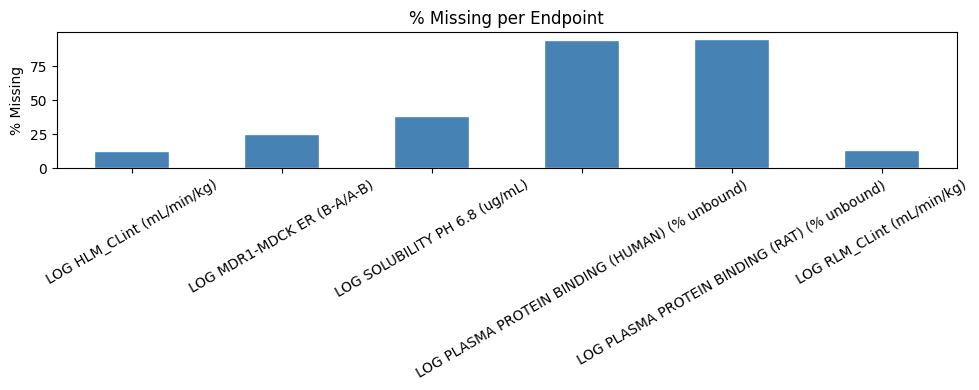

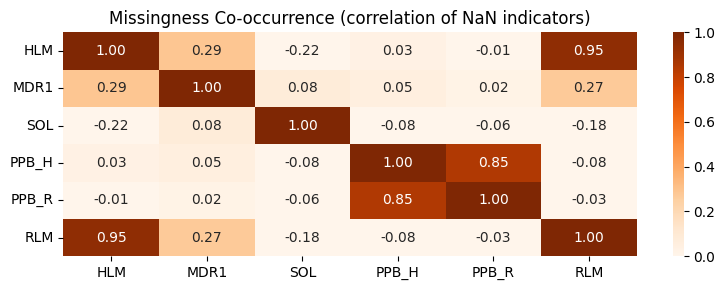

In [6]:
import os
os.makedirs('../figures', exist_ok=True)

miss_report = missing_value_report(df, ENDPOINT_COLS)
print('Missing values per endpoint:')
display(miss_report)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
miss_report['pct_missing'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('% Missing per Endpoint')
ax.set_ylabel('% Missing')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../figures/1.2_missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap of missingness pattern
miss_matrix = df[ENDPOINT_COLS].isna().astype(int)
miss_matrix.columns = EP_SHORT

fig, ax = plt.subplots(figsize=(8, 3))
miss_corr = miss_matrix.corr()
sns.heatmap(miss_corr, annot=True, fmt='.2f', cmap='Oranges', ax=ax, vmin=0, vmax=1)
ax.set_title('Missingness Co-occurrence (correlation of NaN indicators)')
plt.tight_layout()
plt.savefig('../figures/1.2_missingness_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

HLM/RLM correlated in missingness -> Not all compounds tested so if a compound wasnt sent to the lab, its likely to be missing both not one or the other?

PPB_ H/R Same story, correlated as generally tested together?

#### 1.4b — Maximum Possible Correlation (WIP)

Upper bound on the Pearson r any model could achieve for each endpoint, given the assay's measurement noise.  
Uses the Brown, Muchmore & Hajduk simulation: adds Gaussian noise of magnitude `error` to the observed values and correlates against the originals over 1000 iterations.  
A model's r can be interpreted relative to this ceiling.

In [7]:
mc_report = max_corr_report(df, ENDPOINT_COLS)
mc_report.index = EP_SHORT
print('Maximum possible R² per endpoint at 2x, 3x, 5x, 10x assay noise (Brown, Muchmore & Hajduk):')
display(mc_report.round(3))

Maximum possible R² per endpoint at 2x, 3x, 5x, 10x assay noise (Brown, Muchmore & Hajduk):


,n,2-Fold,3-Fold,5-Fold,10-Fold
HLM,3087,0.8110,0.6310,0.4440,0.2800
MDR1,2642,0.8400,0.6760,0.4930,0.3220
SOL,2173,0.8380,0.6720,0.4900,0.3180
PPB_H,194,0.8880,0.7610,0.5980,0.4180
PPB_R,168,0.8770,0.7370,0.5680,0.3880
RLM,3054,0.8610,0.7120,0.5360,0.3600


## 1.5 — Summary Statistics

In [8]:
desc = df[ENDPOINT_COLS].describe().T

skew = df[ENDPOINT_COLS].apply(lambda x: stats.skew(x.dropna()))
kurt = df[ENDPOINT_COLS].apply(lambda x: stats.kurtosis(x.dropna()))

desc['skewness'] = skew
desc['kurtosis'] = kurt
desc.index = EP_SHORT

print('Summary statistics (all 6 endpoints):')
display(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

display(desc[['skewness', 'kurtosis']])

Summary statistics (all 6 endpoints):


,count,mean,std,min,25%,50%,75%,max
HLM,3087.0000,1.3200,0.6240,0.6757,0.6757,1.2053,1.8031,3.3727
MDR1,2642.0000,0.3978,0.6885,-1.1624,-0.1624,0.1533,0.9050,2.7251
SOL,2173.0000,1.2599,0.6834,-1.0000,1.1535,1.5428,1.6874,2.1793
PPB_H,194.0000,0.7657,0.8479,-1.5935,0.1681,0.8676,1.5020,2.0000
PPB_R,168.0000,0.7642,0.7990,-1.6383,0.2266,0.7764,1.3760,2.0000
RLM,3054.0000,2.2562,0.7504,1.0279,1.6883,2.3111,2.8353,3.9696


,skewness,kurtosis
HLM,0.6195,-0.6704
MDR1,0.7583,-0.5211
SOL,-1.6436,1.6604
PPB_H,-0.4798,-0.3784
PPB_R,-0.3902,-0.3364
RLM,-0.1074,-0.9859


SOL only column with | skew | > 1

## 1.6 — Outlier Detection

Flag compounds >3σ from the mean per endpoint. Report only — no rows removed.

In [9]:
outlier_summary = {}
outlier_indices = set()

for col in ENDPOINT_COLS:
    col_data = df[col].dropna()
    mu, sigma = col_data.mean(), col_data.std()
    mask = (df[col] - mu).abs() > 3 * sigma
    flagged = df.index[mask & df[col].notna()].tolist()
    outlier_summary[col] = len(flagged)
    outlier_indices.update(flagged)

print('Outlier counts per endpoint (>3σ):')
for k, v in outlier_summary.items():
    print(f"  {k}: {v}")
print(f"\nUnique compounds flagged in any endpoint: {len(outlier_indices)}")

if outlier_indices:
    print('\nFlagged rows (first 20):')
    display(df.loc[sorted(outlier_indices)[:20], ['Internal ID', 'SMILES'] + ENDPOINT_COLS])

Outlier counts per endpoint (>3σ):
  LOG HLM_CLint (mL/min/kg): 3
  LOG MDR1-MDCK ER (B-A/A-B): 1
  LOG SOLUBILITY PH 6.8 (ug/mL): 20
  LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound): 0
  LOG PLASMA PROTEIN BINDING (RAT) (% unbound): 1
  LOG RLM_CLint (mL/min/kg): 0

Unique compounds flagged in any endpoint: 25

Flagged rows (first 20):


,Internal ID,SMILES,LOG HLM_CLint (mL/min/kg),LOG MDR1-MDCK ER (B-A/A-B),LOG SOLUBILITY PH 6.8 (ug/mL),LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound),LOG PLASMA PROTEIN BINDING (RAT) (% unbound),LOG RLM_CLint (mL/min/kg)
97,Mol98,CCC1=C(C)CN(C(=O)NCCc2ccc(S(=O)(=O)NC(=O)N[C@H...,1.2843,1.8361,NaN,-1.1805,-1.6383,2.4846
303,Mol304,COc1ccccc1CNC(=O)C(C)N1CCCN(c2ccccc2C#N)CC1,3.3399,0.1781,1.6707,NaN,NaN,3.6044
909,Mol910,CC(C(=O)N1CCc2sccc2C1)N1CCCN(c2ccccc2C#N)CC1,3.3282,-0.0598,1.4082,NaN,NaN,3.6266
1914,Mol1915,c1nn(C2CCOCC2)cc1Nc1ncc2nnn(-c3ccc4cn[nH]c4c3)...,1.9858,2.7251,NaN,NaN,NaN,2.8839
2787,Mol2788,Cc1cc(C)nc(SCC(=O)N2c3ccccc3C(C)(c3ccccc3)CC2(...,3.3727,NaN,NaN,NaN,NaN,3.4953
3067,Mol3068,COc1ccc([C@H]2c3[nH]c4ccc(Cl)cc4c3CCN2C(=O)Oc2...,NaN,-0.3646,-1.0000,1.5129,1.7546,NaN
3135,Mol3136,Fc1cccc(Cn2nnc(-c3ccccc3)n2)c1F,NaN,-0.4464,-1.0000,NaN,NaN,NaN
3158,Mol3159,COc1ccc2nc(C(=O)Nc3cnc4c(cnn4C(C)C)c3)ccc2c1,NaN,-0.3336,-0.8239,NaN,NaN,NaN
3190,Mol3191,Cc1cc(C)c(-c2csc(NC(=O)Cn3cnnn3)n2)c(C)c1,NaN,0.8859,-0.9208,NaN,NaN,NaN
3199,Mol3200,Cc1nc(Nc2ccc(F)cc2)nc2c1ncn2-c1ccc(F)cc1,NaN,-0.4113,-0.8539,NaN,NaN,NaN


Consider IQR outlier detection, better for skewed data

## 1.7 — Endpoint Distributions

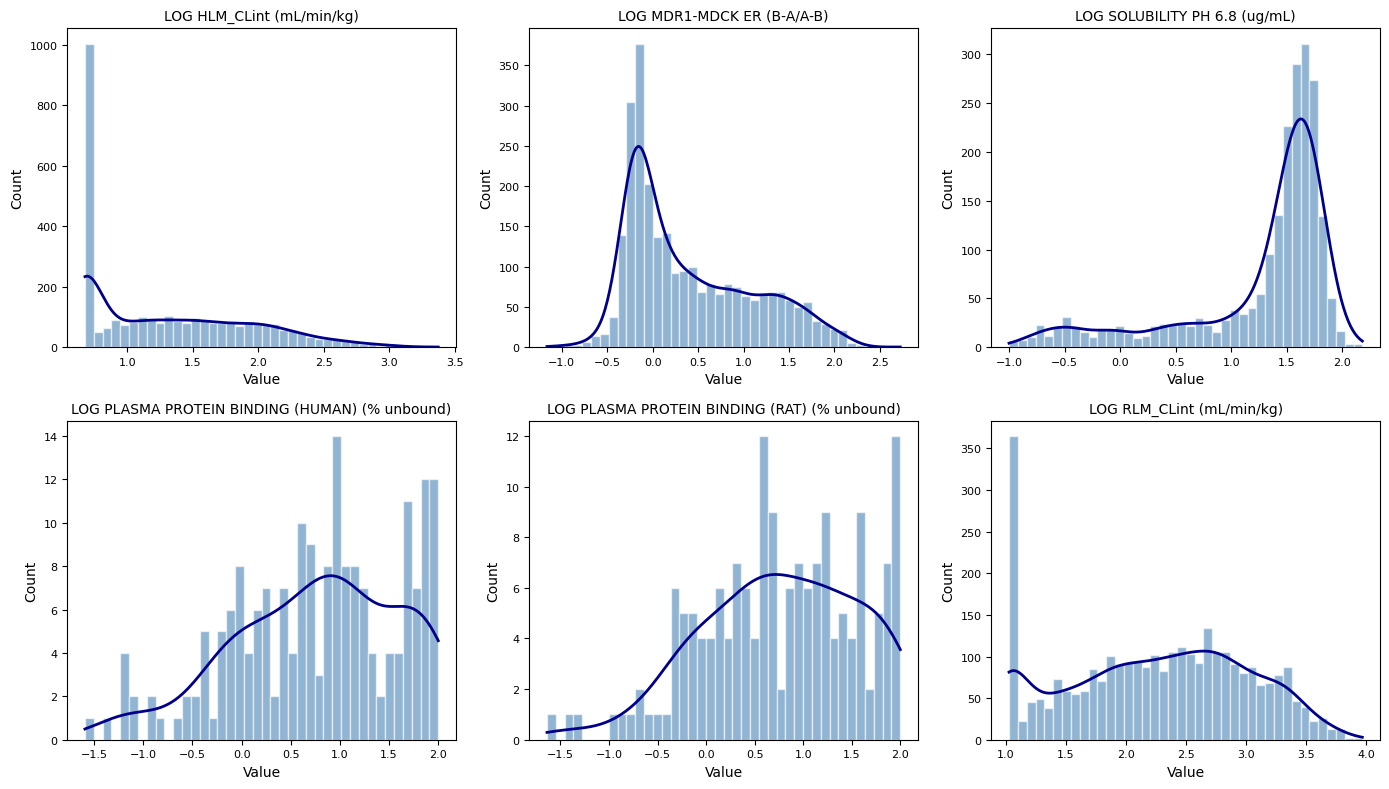

In [10]:
fig = endpoint_distributions(df, ENDPOINT_COLS)
plt.savefig('../figures/1.3_endpoint_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution notes**:
- HLM_CLint: +ve skew, tail points right
- MDR1-MDCK ER: +ve skew
- SOLUBILITY: -ve skew
- PPB HUMAN: mild -ve skew
- PPB RAT: mild -ve skew
- RLM_CLint: No strong peak

**Floor-value spike in HLM_CLint and RLM_CLint**

The first bin spike visible in HLM_CLint and RLM_CLint is not a single outlier — it is a large cluster of compounds sharing the exact same minimum value:

| Endpoint | Floor value (log) | Compounds at floor | % of endpoint data |
|---|---|---|---|
| HLM_CLint | 0.676 | 958 | 31.0% |
| RLM_CLint | 1.028 | 346 | 11.3% |

The cause is currently unknown — possibilities include a lower limit of quantification when the measurements were taken in the lab.

**Why IQR does not flag it**: for HLM, Q1 equals the floor value (0.676) because >25% of the data sits there. The IQR lower bound is therefore −1.015 — well below any observed value — so no compound is flagged.

**Decision**: keep floor values as-is. All models see the same systematic pattern, so relative comparisons remain valid. The practical effect is that models partially learn to predict the floor for a large fraction of compounds, which may inflate apparent accuracy near that value.

## 1.8 — Endpoint Correlations

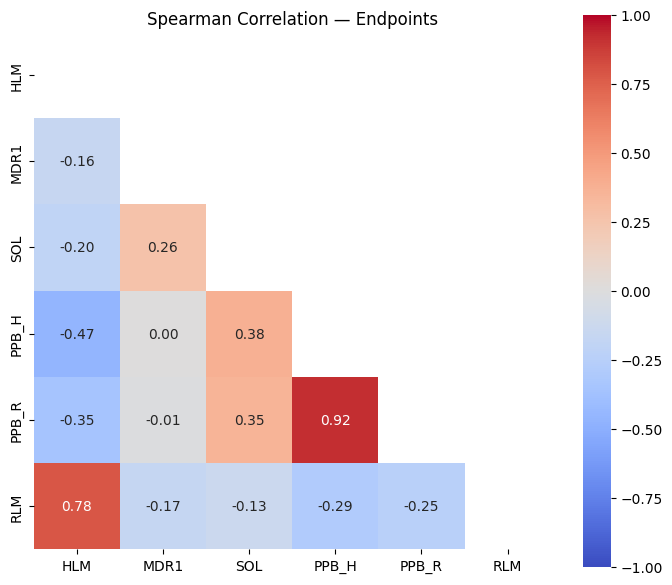

In [11]:
corr = df[ENDPOINT_COLS].corr(method='spearman')
corr.index = corr.columns = EP_SHORT

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax, square=True
)
ax.set_title('Spearman Correlation — Endpoints')
plt.tight_layout()
plt.savefig('../figures/1.8_endpoint_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.9 — Chemical Space Overview

In [12]:
# Pre-validate SMILES before featurising — rdkit_descriptors raises on invalid input
assert validity["invalid_count"] == 0, f"Fix {validity['invalid_count']} invalid SMILES before featurising"

# Compute RDKit 2D descriptors (uses only valid SMILES)
desc_df = rdkit_descriptors(df['SMILES'].tolist())
desc_df.index = df.index
print('Descriptor shape:', desc_df.shape)
display(desc_df.describe())

Descriptor shape: (3521, 6)


,MW,LogP,TPSA,HBD,HBA,RotBonds
count,3521.0000,3521.0000,3521.0000,3521.0000,3521.0000,3521.0000
mean,323.8563,2.8098,63.9421,1.0148,4.5180,4.0432
std,75.9329,1.1720,21.6192,0.8290,1.5968,1.8797
min,150.1450,-1.9800,3.2400,0.0000,1.0000,0.0000
25%,268.3200,2.0532,49.3300,1.0000,3.0000,3.0000
50%,313.7920,2.7828,60.1500,1.0000,4.0000,4.0000
75%,364.4890,3.5326,74.4400,1.0000,5.0000,5.0000
max,1097.3980,9.0141,258.5200,8.0000,16.0000,35.0000


MW = Molecular weight
LogP = Lipophilicity
TPSA = Topological polar surface area - absorption/permeability
HBD = H-bond donors
HBA = H-bond acceptors
RotBonds = Rotatable single bonds - flexibility

lipophiliicty - how fat loving molec is
tpa - tracks with molec weight§§

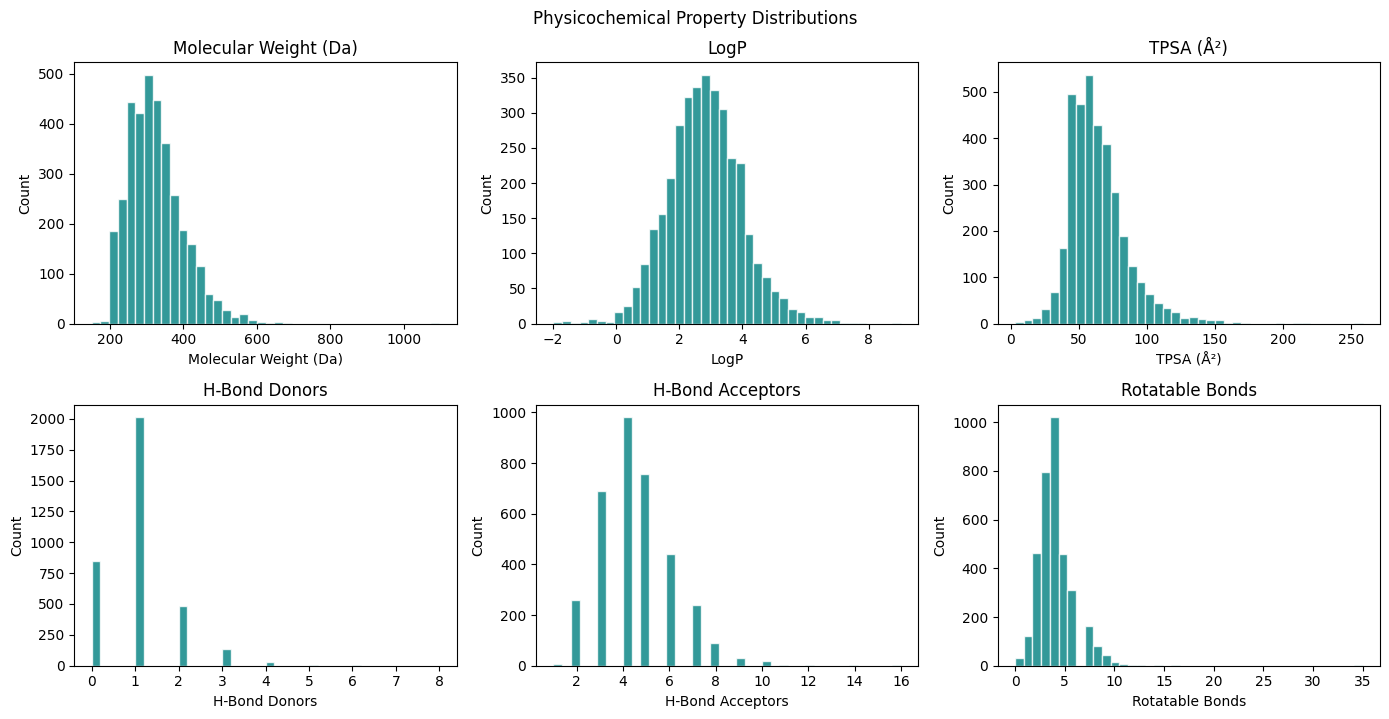

In [13]:
# Histograms of physicochemical properties
prop_labels = {
    'MW': 'Molecular Weight (Da)',
    'LogP': 'LogP',
    'TPSA': 'TPSA (Å²)',
    'HBD': 'H-Bond Donors',
    'HBA': 'H-Bond Acceptors',
    'RotBonds': 'Rotatable Bonds',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (col, label) in zip(axes.flatten(), prop_labels.items()):
    data = desc_df[col].dropna()
    ax.hist(data, bins=40, color='teal', edgecolor='white', alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.suptitle('Physicochemical Property Distributions', y=1.02)
plt.savefig('../figures/1.5_physicochemical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Lipinski Ro5 violations (informational only)
lip_violations = (
    (desc_df['MW'] > 500).astype(int) +
    (desc_df['LogP'] > 5).astype(int) +
    (desc_df['HBD'] > 5).astype(int) +
    (desc_df['HBA'] > 10).astype(int)
)

print('Lipinski Ro5 violations per compound:')
print(lip_violations.value_counts().sort_index())
print(f"\nCompounds with >=2 violations (Ro5 fails): {(lip_violations >= 2).sum()} "
      f"({(lip_violations >= 2).mean()*100:.1f}%)")

Lipinski Ro5 violations per compound:
0    3332
1     148
2      39
3       1
4       1
Name: count, dtype: int64

Compounds with >=2 violations (Ro5 fails): 41 (1.2%)


heuristic, analysis of all drugs FDA approved, found trend that 5 rules that generally observable in drugs approved

3332 compounds break 0 rules, 148 break 1 rule etc

## 1.9b — Pairwise Chemical Similarity Distribution

How diverse is the compound library? If most compounds are very similar (high Tanimoto), the dataset is clustered around a few scaffolds; if similarity is low, the library covers a broad chemical space.

**Method**: Tanimoto similarity on ECFP4 Morgan fingerprints (radius=2, 2048 bits). For N compounds, there are N×(N−1)/2 unique pairs. RDKit's `BulkTanimotoSimilarity` computes all similarities of one fingerprint against a list in a single C++ call — much faster than a Python double loop.

**How Tanimoto works**: Each molecule is represented as a binary fingerprint (bit vector). The Tanimoto coefficient between two fingerprints A and B is:

$$T(A,B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{bits on in both}}{\text{bits on in either}}$$

- T = 1.0 → identical fingerprints (same substructure features)
- T = 0.0 → no shared bits (completely different features)
- T ≈ 0.3–0.5 → typical for unrelated drug-like molecules

In [15]:
# ── Small subsample demo: how BulkTanimotoSimilarity works ───────────────────
from rdkit.Chem import AllChem
from rdkit import Chem, DataStructs

# Pick 5 molecules to illustrate
demo_smiles = df['SMILES'].iloc[:5].tolist()
demo_fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), radius=2, nBits=2048)
            for s in demo_smiles]

# BulkTanimotoSimilarity: compute similarity of fp[0] against ALL others in one C++ call
sims_to_first = DataStructs.BulkTanimotoSimilarity(demo_fps[0], demo_fps[1:])
print('Tanimoto similarities of compound 0 vs compounds 1–4:')
for i, sim in enumerate(sims_to_first, start=1):
    print(f'  0 vs {i}: {sim:.3f}')

# For all unique pairs (upper triangle), we loop i and use Bulk for each row
print(f'\nAll pairwise similarities (5 compounds, {5*4//2} unique pairs):')
for i in range(len(demo_fps)):
    sims = DataStructs.BulkTanimotoSimilarity(demo_fps[i], demo_fps[i+1:])
    for j, sim in enumerate(sims, start=i+1):
        print(f'  {i} vs {j}: {sim:.3f}')

Tanimoto similarities of compound 0 vs compounds 1–4:
  0 vs 1: 0.159
  0 vs 2: 0.115
  0 vs 3: 0.126
  0 vs 4: 0.155

All pairwise similarities (5 compounds, 10 unique pairs):
  0 vs 1: 0.159
  0 vs 2: 0.115
  0 vs 3: 0.126
  0 vs 4: 0.155
  1 vs 2: 0.094
  1 vs 3: 0.157
  1 vs 4: 0.575
  2 vs 3: 0.086
  2 vs 4: 0.086
  3 vs 4: 0.140


In [16]:
# ── Full dataset pairwise similarity distribution ────────────────────────────
# 3521 compounds → 3521×3520/2 = 6,196,960 unique pairs

all_smiles = df['SMILES'].tolist()
all_fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), radius=2, nBits=2048)
           for s in all_smiles]
print(f'Computed {len(all_fps)} fingerprints')

# Collect all pairwise Tanimoto similarities using BulkTanimotoSimilarity
all_sims = []
for i in range(len(all_fps)):
    sims = DataStructs.BulkTanimotoSimilarity(all_fps[i], all_fps[i+1:])
    all_sims.extend(sims)

all_sims = np.array(all_sims)
print(f'Pairwise similarities: {len(all_sims):,} pairs')
print(f'Mean: {all_sims.mean():.3f}, Median: {np.median(all_sims):.3f}, '
      f'Std: {all_sims.std():.3f}')
print(f'Min: {all_sims.min():.3f}, Max: {all_sims.max():.3f}')

Computed 3521 fingerprints
Pairwise similarities: 6,196,960 pairs
Mean: 0.124, Median: 0.119, Std: 0.043
Min: 0.000, Max: 0.978


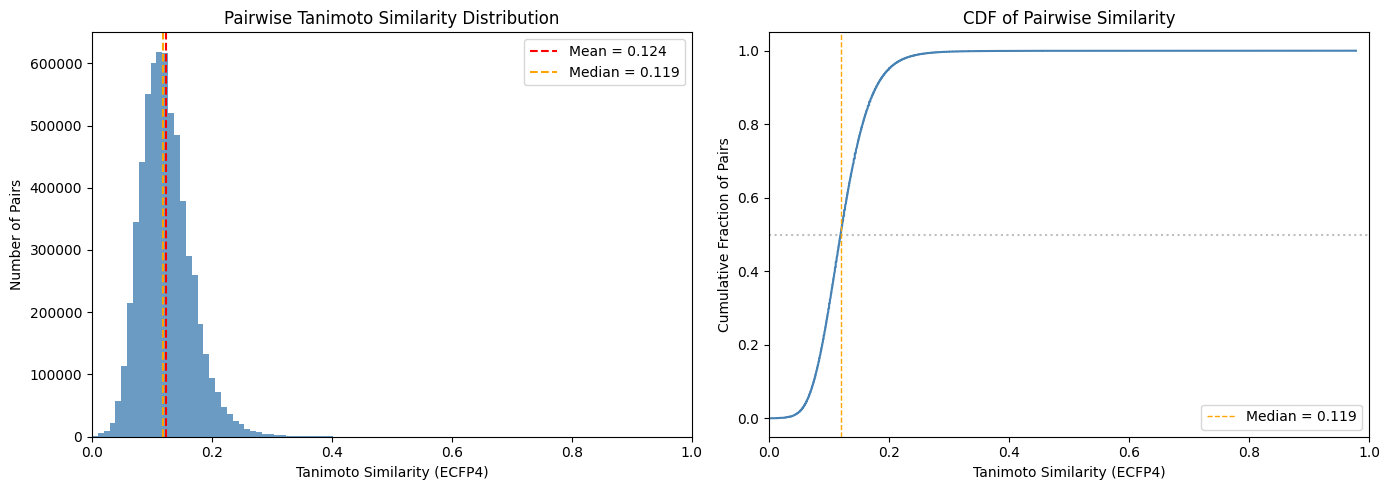

Pairs with Tanimoto >= 0.3: 0.3%
Pairs with Tanimoto >= 0.5: 0.0%
Pairs with Tanimoto >= 0.7: 0.0%
Pairs with Tanimoto >= 0.85: 0.0%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(all_sims, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].axvline(all_sims.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {all_sims.mean():.3f}')
axes[0].axvline(np.median(all_sims), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median = {np.median(all_sims):.3f}')
axes[0].set_xlabel('Tanimoto Similarity (ECFP4)')
axes[0].set_ylabel('Number of Pairs')
axes[0].set_title('Pairwise Tanimoto Similarity Distribution')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Cumulative distribution
sorted_sims = np.sort(all_sims)
cdf = np.arange(1, len(sorted_sims) + 1) / len(sorted_sims)
axes[1].plot(sorted_sims, cdf, color='steelblue', linewidth=1.5)
axes[1].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
axes[1].axvline(np.median(all_sims), color='orange', linestyle='--', linewidth=1,
                label=f'Median = {np.median(all_sims):.3f}')
axes[1].set_xlabel('Tanimoto Similarity (ECFP4)')
axes[1].set_ylabel('Cumulative Fraction of Pairs')
axes[1].set_title('CDF of Pairwise Similarity')
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('../figures/1.6_pairwise_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics by threshold
for thresh in [0.3, 0.5, 0.7, 0.85]:
    frac = (all_sims >= thresh).mean() * 100
    print(f'Pairs with Tanimoto >= {thresh}: {frac:.1f}%')

## 1.10 — EDA Conclusions

> Findings are documented; cleaning strategy (SYNC-002) decided post-EDA review.

### Invalid SMILES
- **Finding**: 0 invalid SMILES out of 3521 (100% valid). No action required.

### Duplicates
- **Finding**: 0 duplicate raw SMILES; 0 duplicate canonical SMILES. Dataset is clean on this front.

### Missingness
- **Finding**: Missingness varies dramatically by endpoint:
  - HLM: 434 missing (12.3%), RLM: 467 missing (13.3%) — manageable
  - MDR1: 879 missing (25.0%), SOL: 1348 missing (38.3%) — substantial
  - PPB_HUMAN: 3327 missing (94.5%), PPB_RAT: 3353 missing (95.2%) — near-complete missingness
- **Cleaning strategy to decide (SYNC-002)**: PPB endpoints are nearly empty. Per-endpoint filtering (train each model on rows with non-missing values for that endpoint) is strongly preferred over complete-cases (which would leave only ~5% of data).

### Endpoint Distributions & Outliers
- **Skewness**: SOLUBILITY is left-skewed (skew=-1.64); HLM and MDR1 are mildly right-skewed (~0.6–0.8); RLM, PPB endpoints near-symmetric.
- **Outliers (>3σ)**: SOLUBILITY has 20 flagged outliers — largest concern. HLM: 3, MDR1: 1, PPB_RAT: 1. ~25 unique compounds flagged across all endpoints.
- **Endpoints to watch**: SOLUBILITY (high skew + most outliers + high missingness).

### Chemical Space
- **Drug-likeness**: 94.7% of compounds have 0 Lipinski Ro5 violations.
- **Violations**: 148 compounds have 1 violation, 41 have ≥2 (Ro5 fails).

## 1.10a — Stereoisomer Exclusion Check

Check for stereoisomer pairs with >3-fold difference in any log-scale endpoint. Following the filtering criterion in Fang et al. (ADME prospective validation paper), we flag and exclude any such pairs found.

**Why this matters**: Our ECFP4 fingerprints are computed with `useChirality=False` (the standard default), so the Morgan algorithm ignores stereochemistry annotations (R/S, E/Z). Two stereoisomers share the same atom connectivity and differ only in 3D spatial arrangement, producing **identical fingerprint bit vectors**. If they also differ substantially in activity, the model sees the same input for different target values — irresolvable label noise.

> **Why not set `useChirality=True`?** Stereochemistry annotations in SMILES are often incomplete or inconsistent across datasets; encoding unreliable chirality can introduce more noise than it resolves. The chirality-off default is standard practice in QSAR fingerprinting for this reason.

In [18]:
from src.cleaning import exclude_stereoisomer_pairs

n_before = len(df)
df, excluded_stereo = exclude_stereoisomer_pairs(df, 'SMILES', ENDPOINT_COLS, fold_threshold=3)
n_after = len(df)

print(f'Stereoisomer exclusion (>3-fold difference in any log-scale endpoint):')
print(f'  Compounds before: {n_before}')
print(f'  Excluded:         {n_before - n_after}  (indices: {excluded_stereo})')
print(f'  Compounds after:  {n_after}')

Stereoisomer exclusion (>3-fold difference in any log-scale endpoint):
  Compounds before: 3521
  Excluded:         0  (indices: [])
  Compounds after:  3521


## 1.11 — IQR Outlier Detection

Flag compounds outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR] per endpoint.  
**Policy**: flag only — no rows removed. Outliers are kept for now, can look into how their exclusion later affects performance.  
Note: 3σ detection was used in Section 1.6 for reference; IQR is preferred here as it is more robust for skewed distributions (SOLUBILITY skewness = −1.64).

In [19]:
from src.cleaning import flag_iqr_outliers, filter_endpoint

iqr_outlier_summary = {}

for col, short in zip(ENDPOINT_COLS, EP_SHORT):
    tag_col = f'iqr_outlier_{short}'
    df[tag_col] = False
    df_ep = filter_endpoint(df, col)
    mask = flag_iqr_outliers(df_ep, col)
    df.loc[mask[mask].index, tag_col] = True
    iqr_outlier_summary[col] = int(mask.sum())

print('IQR outlier counts per endpoint (1.5×IQR rule, flag only):')
for col, n in iqr_outlier_summary.items():
    print(f'  {col}: {n}')

print('\nOutlier tag columns added to df:', [f'iqr_outlier_{s}' for s in EP_SHORT])
print('\nExample — SOL outliers:')
display(df[df['iqr_outlier_SOL']][['Internal ID', 'SMILES', 'LOG SOLUBILITY PH 6.8 (ug/mL)']].head())

IQR outlier counts per endpoint (1.5×IQR rule, flag only):
  LOG HLM_CLint (mL/min/kg): 0
  LOG MDR1-MDCK ER (B-A/A-B): 1
  LOG SOLUBILITY PH 6.8 (ug/mL): 276
  LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound): 0
  LOG PLASMA PROTEIN BINDING (RAT) (% unbound): 1
  LOG RLM_CLint (mL/min/kg): 0

Outlier tag columns added to df: ['iqr_outlier_HLM', 'iqr_outlier_MDR1', 'iqr_outlier_SOL', 'iqr_outlier_PPB_H', 'iqr_outlier_PPB_R', 'iqr_outlier_RLM']

Example — SOL outliers:


,Internal ID,SMILES,LOG SOLUBILITY PH 6.8 (ug/mL)
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.0899
26,Mol27,Cn1cc(-c2cn3nccc3c(-c3cnn([C@]4(CC#N)C[C@@H](C...,0.3424
147,Mol148,O=C(Nc1nc2cc(C(F)(F)F)cc(NC3CC3)n2n1)c1cccnc1,0.0414
262,Mol263,CC(C)(C)c1cc(NC(=O)c2cccc3cn[nH]c23)[nH]n1,0.2504
281,Mol282,O=C(CCCc1nnc(-c2ccccc2)o1)Nc1cccc2ccccc12,0.1173


## 1.12 — Per-Endpoint Row Counts

Effective N for each model under per-endpoint filtering.  
PPB models (~170–190 rows) will have wider confidence intervals than HLM/RLM models (~3000 rows).

In [20]:
from src.cleaning import filter_endpoint

header = f"{'Endpoint':<52} {'N_total':>7} {'N_missing':>10} {'N_for_model':>13} {'IQR_outliers':>13}"
print(header)
print('-' * len(header))

for col, short in zip(ENDPOINT_COLS, EP_SHORT):
    n_missing = int(df[col].isna().sum())
    n_model = len(filter_endpoint(df, col))
    n_iqr = iqr_outlier_summary[col]
    print(f'  {short:<50} {len(df):>7} {n_missing:>10} {n_model:>13} {n_iqr:>13}')

Endpoint                                             N_total  N_missing   N_for_model  IQR_outliers
---------------------------------------------------------------------------------------------------
  HLM                                                   3521        434          3087             0
  MDR1                                                  3521        879          2642             1
  SOL                                                   3521       1348          2173           276
  PPB_H                                                 3521       3327           194             0
  PPB_R                                                 3521       3353           168             1
  RLM                                                   3521        467          3054             0


---

# Part 2 — Featurization & Baseline Models

**Goal**: Train 6 baseline regressors (MeanPredictor dummy + 5 real models) on all 6 ADME endpoints using ECFP4 Morgan fingerprints; evaluate with R², RMSE, MSE.  
**Models**: MeanPredictor (dummy baseline), Ridge, BayesianRidge, RandomForest, XGBoost, LightGBM  
**Featurization**: ECFP4 Morgan fingerprints (radius=2, 2048 bits) — see `src/features.morgan_fingerprints`

## 2.1 — Featurization

Generate ECFP4 Morgan fingerprints (radius=2, 2048 bits) for each per-endpoint filtered subset.

In [21]:
from src.features import morgan_fingerprints
from src.cleaning import filter_endpoint

X_dict = {}  # {endpoint_col: (N, 2048) ndarray}
y_dict = {}  # {endpoint_col: (N,) ndarray}

for col in ENDPOINT_COLS:
    df_ep = filter_endpoint(df, col)
    X_dict[col] = morgan_fingerprints(df_ep['SMILES'].tolist())
    y_dict[col] = df_ep[col].values

for col in ENDPOINT_COLS:
    print(f"  {col}: X={X_dict[col].shape}, y={y_dict[col].shape}")

  LOG HLM_CLint (mL/min/kg): X=(3087, 2048), y=(3087,)
  LOG MDR1-MDCK ER (B-A/A-B): X=(2642, 2048), y=(2642,)
  LOG SOLUBILITY PH 6.8 (ug/mL): X=(2173, 2048), y=(2173,)
  LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound): X=(194, 2048), y=(194,)
  LOG PLASMA PROTEIN BINDING (RAT) (% unbound): X=(168, 2048), y=(168,)
  LOG RLM_CLint (mL/min/kg): X=(3054, 2048), y=(3054,)


Compound : Mol1
SMILES   : CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H]3C[C@@H]3F)cnc12
Bits ON  : 64 / 2048  (3.1% density)
First 10 ON-bit indices: [32, 95, 190, 243, 314, 378, 387, 412, 448, 486]


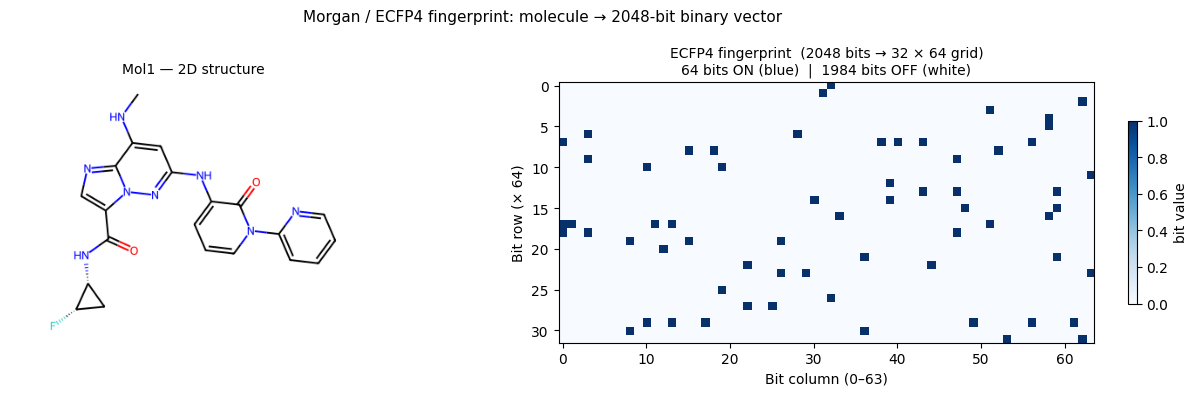


How it works (radius=2 → ECFP4):
  r=0  each atom is hashed individually (element, charge, …)
  r=1  each atom + its direct neighbours
  r=2  each atom + all atoms within 2 bonds     ← ECFP4 uses this
  Each circular environment is hashed to one of the 2048 bit positions.
  Two different environments that hash to the same bit → bit collision (rare at 2048 bits).



In [22]:
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors

# ── Pick first compound from the HLM subset ───────────────────────────────────
hlm_df = filter_endpoint(df, ENDPOINT_COLS[0])
smi = hlm_df.iloc[0]['SMILES']
mol = Chem.MolFromSmiles(smi)

fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
fp_arr = np.array(fp)
n_set = int(fp_arr.sum())

print(f"Compound : {hlm_df.iloc[0]['Internal ID']}")
print(f"SMILES   : {smi[:80]}{'…' if len(smi)>80 else ''}")
print(f"Bits ON  : {n_set} / 2048  ({n_set/2048*100:.1f}% density)")
print(f"First 10 ON-bit indices: {np.where(fp_arr)[0][:10].tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: molecule structure
img = Draw.MolToImage(mol, size=(420, 300))
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f'{hlm_df.iloc[0]["Internal ID"]} — 2D structure', fontsize=10)

# Right: fingerprint as 32×64 grid (each cell = 1 bit)
fp_grid = fp_arr.reshape(32, 64)
im = axes[1].imshow(fp_grid, cmap='Blues', aspect='auto', interpolation='none', vmin=0, vmax=1)
axes[1].set_title(
    f'ECFP4 fingerprint  (2048 bits → 32 × 64 grid)\n'
    f'{n_set} bits ON (blue)  |  {2048-n_set} bits OFF (white)', fontsize=10)
axes[1].set_xlabel('Bit column (0–63)')
axes[1].set_ylabel('Bit row (× 64)')

plt.colorbar(im, ax=axes[1], shrink=0.7, label='bit value')
plt.suptitle('Morgan / ECFP4 fingerprint: molecule → 2048-bit binary vector', fontsize=11)
plt.tight_layout()
plt.show()

print("""
How it works (radius=2 → ECFP4):
  r=0  each atom is hashed individually (element, charge, …)
  r=1  each atom + its direct neighbours
  r=2  each atom + all atoms within 2 bonds     ← ECFP4 uses this
  Each circular environment is hashed to one of the 2048 bit positions.
  Two different environments that hash to the same bit → bit collision (rare at 2048 bits).
""")

In [23]:
# ── Part A: how radius controls what each bit "sees" ─────────────────────────
# Use aspirin — small enough to reason about atom-by-atom
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors

demo_smi = 'CC(=O)Oc1ccccc1C(=O)O'   # aspirin
demo_mol = Chem.MolFromSmiles(demo_smi)

print("Aspirin:", demo_smi)
print()
print("radius  ECFP name   bits ON   interpretation")
print("──────  ─────────   ───────   ──────────────")
for r in [0, 1, 2, 3]:
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(demo_mol, radius=r, nBits=2048)
    n = int(sum(fp))
    desc = {
        0: "each atom alone (element, charge, degree…)",
        1: "each atom + its direct bonds",
        2: "each atom + atoms within 2 bonds  ← ECFP4",
        3: "each atom + atoms within 3 bonds  ← ECFP6",
    }[r]
    print(f"  r={r}    ECFP{r*2}       {n:>4}     {desc}")

print()
print("Going deeper in radius → more context captured per bit → bits grow slowly")
print("(overlapping environments share atoms, so bits don't double each step)")

Aspirin: CC(=O)Oc1ccccc1C(=O)O

radius  ECFP name   bits ON   interpretation
──────  ─────────   ───────   ──────────────
  r=0    ECFP0          6     each atom alone (element, charge, degree…)
  r=1    ECFP2         16     each atom + its direct bonds
  r=2    ECFP4         24     each atom + atoms within 2 bonds  ← ECFP4
  r=3    ECFP6         31     each atom + atoms within 3 bonds  ← ECFP6

Going deeper in radius → more context captured per bit → bits grow slowly
(overlapping environments share atoms, so bits don't double each step)


Aspirin has 24 ON bits at r=2.  Each row below is one bit:

  bit  389  centre=atom12(O)  radius=1
  bit  456  centre=atom10(C)  radius=1
  bit  650  centre=atom2(O)  radius=0
  bit  695  centre=atom3(O)  radius=0
  bit  807  centre=atom1(C)  radius=0
  bit  909  centre=atom4(C)  radius=2
  bit 1017  centre=atom0(C)  radius=1
  bit 1035  centre=atom1(C)  radius=1
  bit 1047  centre=atom10(C)  radius=2
  bit 1057  centre=atom0(C)  radius=0
  bit 1088  centre=atom6(C)  radius=1
  bit 1199  centre=atom6(C)  radius=2
  bit 1380  centre=atom4(C)  radius=0
  bit 1410  centre=atom5(C)  radius=2
  bit 1447  centre=atom8(C)  radius=2
  bit 1468  centre=atom3(O)  radius=2
  bit 1616  centre=atom9(C)  radius=2
  bit 1729  centre=atom3(O)  radius=1
  bit 1750  centre=atom5(C)  radius=1
  bit 1775  centre=atom1(C)  radius=2
  bit 1873  centre=atom5(C)  radius=0
  bit 1917  centre=atom2(O)  radius=1
  bit 1970  centre=atom4(C)  radius=1
  bit 1991  centre=atom9(C)  radius=1


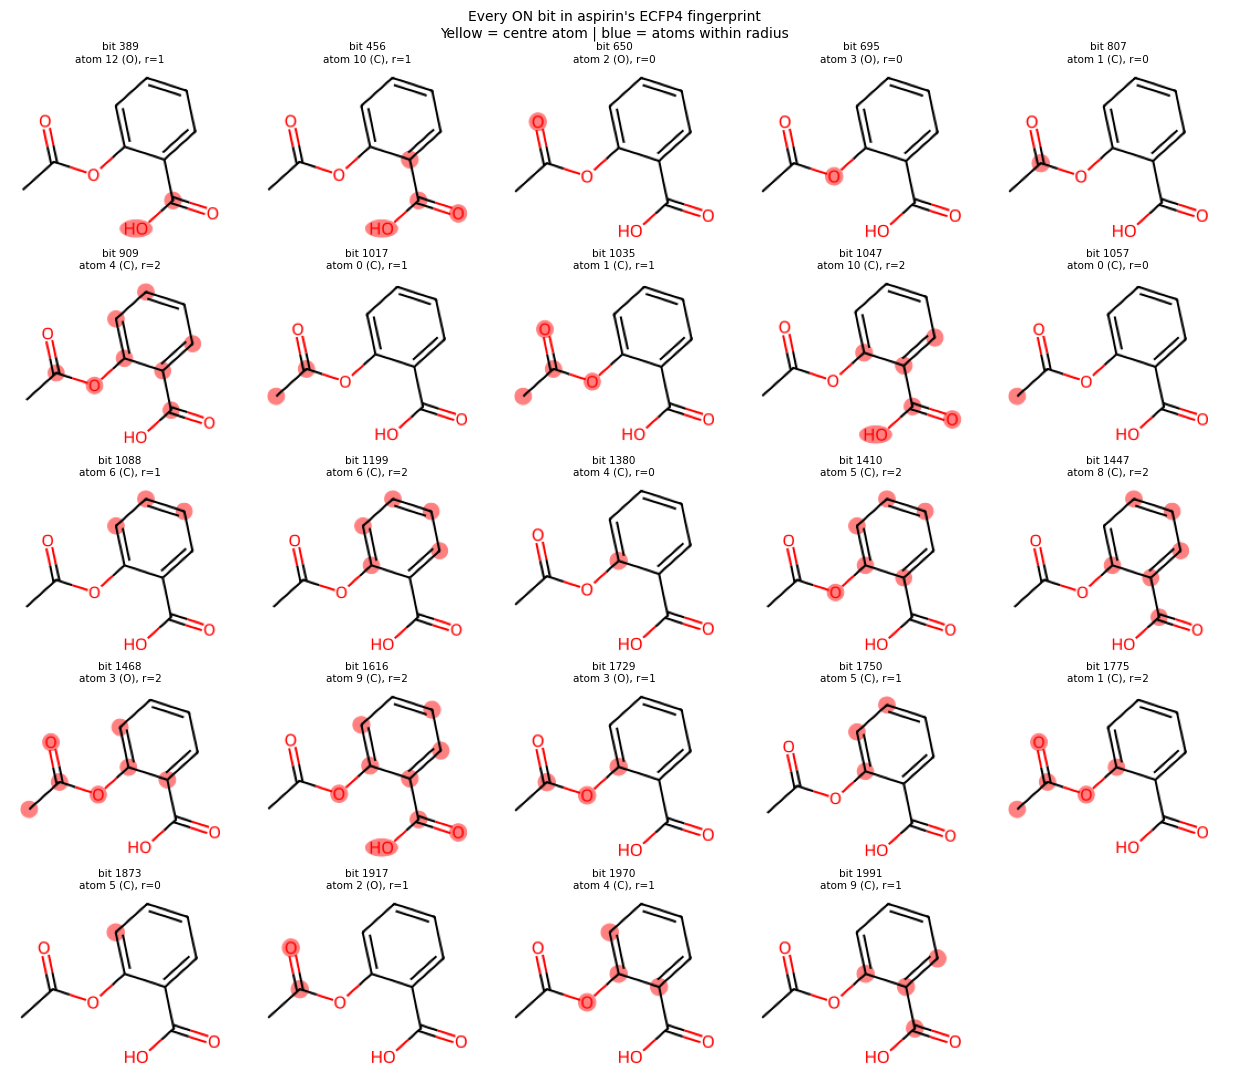

Key insight: each bit = one unique chemical neighbourhood.
The SAME bit fires for ANY molecule that contains that same neighbourhood.


In [24]:
# ── Part B: draw the actual circular environments for each ON bit ─────────────
# DrawMorganBit has a C++ API mismatch in this RDKit build, so we draw manually:
# FindAtomEnvironmentOfRadiusN gives us the bonds in the circular neighbourhood,
# then MolToImage highlights those atoms directly.

def draw_morgan_env(mol, centre_atom, radius, size=(200, 160)):
    """Highlight the Morgan environment of `centre_atom` at `radius`."""
    bond_ids = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, centre_atom)
    env_atoms = {centre_atom}
    for bid in bond_ids:
        b = mol.GetBondWithIdx(bid)
        env_atoms.add(b.GetBeginAtomIdx())
        env_atoms.add(b.GetEndAtomIdx())

    colors = {a: (1.0, 0.85, 0.0) if a == centre_atom   # yellow  = centre
                 else (0.6, 0.8, 1.0)                    # blue    = neighbourhood
              for a in env_atoms}
    return Draw.MolToImage(mol, size=size,
                           highlightAtoms=list(env_atoms),
                           highlightAtomColors=colors)

bi = {}
rdMolDescriptors.GetMorganFingerprintAsBitVect(demo_mol, radius=2, nBits=2048, bitInfo=bi)
on_bits = sorted(bi.keys())
print(f"Aspirin has {len(on_bits)} ON bits at r=2.  Each row below is one bit:\n")

for bit in on_bits:
    atom_idx, radius = bi[bit][0]
    atom_sym = demo_mol.GetAtomWithIdx(atom_idx).GetSymbol()
    print(f"  bit {bit:4d}  centre=atom{atom_idx}({atom_sym})  radius={radius}")

n_cols = 5
n_rows = -(-len(on_bits) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.2))
axes = axes.flatten()

for ax, bit in zip(axes, on_bits):
    atom_idx, radius = bi[bit][0]
    atom_sym = demo_mol.GetAtomWithIdx(atom_idx).GetSymbol()
    img = draw_morgan_env(demo_mol, atom_idx, radius, size=(200, 160))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'bit {bit}\natom {atom_idx} ({atom_sym}), r={radius}', fontsize=7.5)

for ax in axes[len(on_bits):]:
    ax.axis('off')

plt.suptitle(
    "Every ON bit in aspirin's ECFP4 fingerprint\n"
    "Yellow = centre atom | blue = atoms within radius",
    fontsize=10)
plt.tight_layout()
plt.show()

print("Key insight: each bit = one unique chemical neighbourhood.")
print("The SAME bit fires for ANY molecule that contains that same neighbourhood.")

Reference: Aspirin  (24 bits ON)

Molecule                       bits ON   shared |A∩B|   union |A∪B|   Tanimoto
──────────────────────────────────────────────────────────────────────────────
  Aspirin                           24             24            24      1.000
  Salicylic acid (aspirin −acetyl)      18             13            29      0.448
  Ibuprofen (different scaffold)      25              8            41      0.195
  Caffeine (very different)         25              4            45      0.089

Tanimoto = |A ∩ B| / |A ∪ B|  =  shared / (bits_A + bits_B - shared)
Range 0 (nothing in common) → 1 (identical fingerprint)


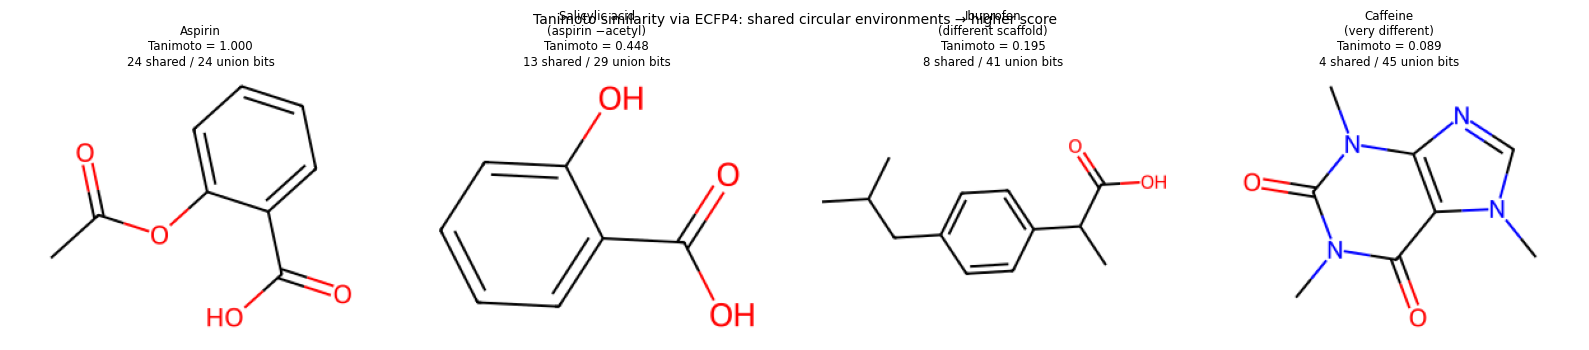

In [25]:
# ── Part C: Tanimoto similarity — how fingerprints measure molecular similarity ─
from rdkit.DataStructs import TanimotoSimilarity

molecules = [
    ('Aspirin',              'CC(=O)Oc1ccccc1C(=O)O'),
    ('Salicylic acid\n(aspirin −acetyl)', 'OC(=O)c1ccccc1O'),
    ('Ibuprofen\n(different scaffold)',   'CC(C)Cc1ccc(cc1)C(C)C(=O)O'),
    ('Caffeine\n(very different)',        'Cn1cnc2c1c(=O)n(C)c(=O)n2C'),
]

ref_name, ref_smi = molecules[0]
ref_fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
    Chem.MolFromSmiles(ref_smi), radius=2, nBits=2048)
ref_on = int(sum(ref_fp))

print(f"Reference: {ref_name}  ({ref_on} bits ON)\n")
print(f"{'Molecule':<30} {'bits ON':>7}  {'shared |A∩B|':>13}  {'union |A∪B|':>12}  {'Tanimoto':>9}")
print("─" * 78)

fps = []
for name, smi in molecules:
    mol_ = Chem.MolFromSmiles(smi)
    fp_ = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol_, radius=2, nBits=2048)
    fps.append(fp_)
    n_on   = int(sum(fp_))
    shared = int(sum(a and b for a, b in zip(ref_fp, fp_)))
    union  = ref_on + n_on - shared
    sim    = TanimotoSimilarity(ref_fp, fp_)
    label  = name.replace('\n', ' ')
    print(f"  {label:<28} {n_on:>7}  {shared:>13}  {union:>12}  {sim:>9.3f}")

print()
print("Tanimoto = |A ∩ B| / |A ∪ B|  =  shared / (bits_A + bits_B - shared)")
print("Range 0 (nothing in common) → 1 (identical fingerprint)")

# Draw all four molecules with their similarity scores
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (name, smi), fp_ in zip(axes, molecules, fps):
    mol_ = Chem.MolFromSmiles(smi)
    img = Draw.MolToImage(mol_, size=(300, 210))
    ax.imshow(img)
    ax.axis('off')
    sim    = TanimotoSimilarity(ref_fp, fp_)
    shared = int(sum(a and b for a, b in zip(ref_fp, fp_)))
    n_on   = int(sum(fp_))
    ax.set_title(f'{name}\nTanimoto = {sim:.3f}\n{shared} shared / {ref_on+n_on-shared} union bits',
                 fontsize=8.5)

plt.suptitle('Tanimoto similarity via ECFP4: shared circular environments → higher score', fontsize=10)
plt.tight_layout()
plt.show()

## 2.2 — Train/Test Split

80/20 random split per endpoint (seed=42 for reproducibility).

In [26]:
from sklearn.model_selection import train_test_split
from src.cleaning import filter_endpoint

splits = {}  # {col: (X_train, X_test, y_train, y_test, smiles_train, smiles_test)}

for col in ENDPOINT_COLS:
    df_ep = filter_endpoint(df, col)
    X, y = X_dict[col], y_dict[col]
    smiles_all = df_ep['SMILES'].tolist()
    X_train, X_test, y_train, y_test, smiles_train, smiles_test = train_test_split(
        X, y, smiles_all, test_size=0.2, random_state=SEED
    )
    splits[col] = (X_train, X_test, y_train, y_test, smiles_train, smiles_test)
    print(f"  {col}: train={len(y_train)}, test={len(y_test)}")

  LOG HLM_CLint (mL/min/kg): train=2469, test=618
  LOG MDR1-MDCK ER (B-A/A-B): train=2113, test=529
  LOG SOLUBILITY PH 6.8 (ug/mL): train=1738, test=435
  LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound): train=155, test=39
  LOG PLASMA PROTEIN BINDING (RAT) (% unbound): train=134, test=34
  LOG RLM_CLint (mL/min/kg): train=2443, test=611


## 2.3 — Model Training & Evaluation

In [27]:
from src.models import get_baseline_models, evaluate_model

results = []
preds_store = {}  # {col: {model_name: (y_test, y_pred)}}

for col in ENDPOINT_COLS:
    X_train, X_test, y_train, y_test, _, _ = splits[col]
    preds_store[col] = {}
    for name, model in get_baseline_models().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        preds_store[col][name] = (y_test, y_pred)
        metrics = evaluate_model(model, X_test, y_test, y_pred=y_pred)
        results.append({"endpoint": col, "model": name, "features": "ECFP4", **metrics})

results_df = pd.DataFrame(results)
print("Training complete.")
print(f"\nMean R² across endpoints per model:")
print(results_df.groupby('model')['R2'].mean().round(3).sort_values(ascending=False).to_string())

/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An

Training complete.

Mean R² across endpoints per model:
model
BayesianRidge    0.3320
XGBoost          0.2950
LightGBM         0.2830
RandomForest     0.2780
Ridge            0.0240
MeanPredictor   -0.0010


## 2.3b — Baselines on RDKit 2D Descriptors

Same 6 baseline models, same train/test splits, but featurized with the full 200-descriptor RDKit 2D normalized set (via `descriptastorus`) instead of Morgan ECFP4. This is the same descriptor set that MPNN2 uses as auxiliary features.

In [28]:
from src.features import rdkit_2d_features
from src.models import get_baseline_models, evaluate_model

# ── Compute RDKit 2D features for each endpoint ───────────────────────────────
X_rdkit_dict = {}
for col in ENDPOINT_COLS:
    df_ep = filter_endpoint(df, col)
    X_rdkit_dict[col] = rdkit_2d_features(df_ep['SMILES'].tolist())
    print(f"  {col}: X_rdkit={X_rdkit_dict[col].shape}")

# ── Split using same random_state → identical molecule partitions ──────────────
splits_rdkit = {}
for col in ENDPOINT_COLS:
    df_ep = filter_endpoint(df, col)
    X_rdkit = X_rdkit_dict[col]
    y = y_dict[col]
    smiles_all = df_ep['SMILES'].tolist()
    X_train, X_test, y_train, y_test, smi_tr, smi_te = train_test_split(
        X_rdkit, y, smiles_all, test_size=0.2, random_state=SEED
    )
    splits_rdkit[col] = (X_train, X_test, y_train, y_test, smi_tr, smi_te)
    # Sanity check: same molecules in train/test as Morgan split
    assert np.array_equal(y_test, splits[col][3]), f"Split mismatch for {col}!"

# ── Train all 6 baselines on RDKit 2D features ────────────────────────────────
results_rdkit = []
preds_store_rdkit = {}

for col in ENDPOINT_COLS:
    X_train, X_test, y_train, y_test, _, _ = splits_rdkit[col]
    preds_store_rdkit[col] = {}
    for name, model in get_baseline_models().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        preds_store_rdkit[col][name] = (y_test, y_pred)
        metrics = evaluate_model(model, X_test, y_test, y_pred=y_pred)
        results_rdkit.append({"endpoint": col, "model": name, "features": "RDKit2D", **metrics})

# ── Merge into results_df ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results + results_rdkit)
results_df['ep_short'] = results_df['endpoint'].map(EP_SHORT_MAP)

print("RDKit 2D training complete.")
print(f"\nMean R² across endpoints — ECFP4 vs RDKit2D:")
print(results_df.groupby(['features', 'model'])['R2'].mean().round(3).unstack('features').to_string())

/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:7087: RuntimeWarning: overflow encountered in _ncf_cdf
  return _boost._ncf_cdf(x, dfn, dfd, nc)


  LOG HLM_CLint (mL/min/kg): X_rdkit=(3087, 200)
  LOG MDR1-MDCK ER (B-A/A-B): X_rdkit=(2642, 200)
  LOG SOLUBILITY PH 6.8 (ug/mL): X_rdkit=(2173, 200)
  LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound): X_rdkit=(194, 200)
  LOG PLASMA PROTEIN BINDING (RAT) (% unbound): X_rdkit=(168, 200)
  LOG RLM_CLint (mL/min/kg): X_rdkit=(3054, 200)


/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An

RDKit 2D training complete.

Mean R² across endpoints — ECFP4 vs RDKit2D:
features        ECFP4  RDKit2D
model                         
BayesianRidge  0.3320   0.4040
LightGBM       0.2830   0.4320
MeanPredictor -0.0010  -0.0010
RandomForest   0.2780   0.4060
Ridge          0.0240   0.3510
XGBoost        0.2950   0.3530


## 2.4 — Results Summary

In [29]:
results_df['ep_short'] = results_df['endpoint'].map(EP_SHORT_MAP)

for feat in results_df['features'].unique():
    subset = results_df[results_df['features'] == feat]
    print(f'R² (test set) — {feat}:')
    r2_table = subset.pivot(index='ep_short', columns='model', values='R2').round(3)
    display(r2_table)
    print(f'\nRMSE (test set) — {feat}:')
    rmse_table = subset.pivot(index='ep_short', columns='model', values='RMSE').round(3)
    display(rmse_table)
    print()

R² (test set) — ECFP4:


model,BayesianRidge,LightGBM,MeanPredictor,RandomForest,Ridge,XGBoost
ep_short,,,,,,
HLM,0.3200,0.3290,-0.0010,0.2640,-0.2030,0.2880
MDR1,0.3890,0.3980,-0.0010,0.3460,0.0220,0.3190
PPB_H,0.1340,0.0300,-0.0030,0.0740,0.1240,0.1570
PPB_R,0.4870,0.2850,-0.0040,0.4420,0.4940,0.4380
RLM,0.3890,0.3780,-0.0000,0.3020,-0.1730,0.3460
SOL,0.2770,0.2780,-0.0000,0.2380,-0.1190,0.2210



RMSE (test set) — ECFP4:


model,BayesianRidge,LightGBM,MeanPredictor,RandomForest,Ridge,XGBoost
ep_short,,,,,,
HLM,0.5110,0.5080,0.6200,0.5320,0.6800,0.5230
MDR1,0.5270,0.5220,0.6740,0.5450,0.6660,0.5560
PPB_H,0.7630,0.8070,0.8210,0.7890,0.7670,0.7530
PPB_R,0.5650,0.6670,0.7910,0.5900,0.5610,0.5920
RLM,0.5830,0.5880,0.7450,0.6230,0.8070,0.6030
SOL,0.5840,0.5840,0.6870,0.6000,0.7270,0.6060



R² (test set) — RDKit2D:


model,BayesianRidge,LightGBM,MeanPredictor,RandomForest,Ridge,XGBoost
ep_short,,,,,,
HLM,0.3780,0.4810,-0.0010,0.4060,0.3820,0.4300
MDR1,0.4770,0.5070,-0.0010,0.4500,0.4850,0.4280
PPB_H,0.3660,0.3310,-0.0030,0.3090,0.2930,0.2730
PPB_R,0.6020,0.5540,-0.0040,0.5830,0.3860,0.4100
RLM,0.3640,0.4770,-0.0000,0.4460,0.3620,0.4380
SOL,0.2390,0.2410,-0.0000,0.2450,0.1980,0.1390



RMSE (test set) — RDKit2D:


model,BayesianRidge,LightGBM,MeanPredictor,RandomForest,Ridge,XGBoost
ep_short,,,,,,
HLM,0.4890,0.4470,0.6200,0.4780,0.4870,0.4680
MDR1,0.4870,0.4730,0.6740,0.4990,0.4830,0.5090
PPB_H,0.6530,0.6700,0.8210,0.6820,0.6890,0.6990
PPB_R,0.4980,0.5270,0.7910,0.5100,0.6180,0.6060
RLM,0.5940,0.5390,0.7450,0.5550,0.5950,0.5590
SOL,0.5990,0.5990,0.6870,0.5970,0.6150,0.6380


Notes:

1. Ridge performs poorly on ECFP4, better on RDKit2D, bayesian ridge has regularization that results in sparse binary inputs not being so much of an issue
2. RDKit2D > ECFP4 Wonder why? Whats the main diff between the 2 featurization approaches?
3. Tree based methods surpass BayesianRidge

Note 2:
- ECFP4: binary circular fingerprint — encodes which structural fragments are present (topology). 2048 sparse binary bits. Captures "what the molecule looks like structurally."
- RDKit2D: ~200 continuous physicochemical descriptors — MW, LogP, TPSA, H-bond donors/acceptors, rotatable bonds, ring counts, etc.


## 2.4b — Fingerprint Radius Sensitivity (r=1, 2, 4)

Same 5 baseline models, same 80/20 split, same endpoints — only the Morgan fingerprint radius varies. Radius controls how large a circular neighbourhood each bit encodes: r=1 captures immediate bonds, r=2 (ECFP4, our default) extends two bonds out, r=4 (ECFP8) captures larger structural contexts. MeanPredictor excluded as it ignores fingerprints entirely.

In [30]:
if not RUN_RADIUS_SENSITIVITY:
    print('Radius sensitivity skipped (RUN_RADIUS_SENSITIVITY=False).')
else:
    from src.features import morgan_fingerprints
    from src.cleaning import filter_endpoint
    from sklearn.model_selection import train_test_split

    RADII = [1, 2, 4]
    radius_rows = []

    for radius in RADII:
        for col in ENDPOINT_COLS:
            df_ep = filter_endpoint(df, col)
            X_r = morgan_fingerprints(df_ep['SMILES'].tolist(), radius=radius)
            y_r = df_ep[col].values
            X_train, X_test, y_train, y_test = train_test_split(X_r, y_r, test_size=0.2, random_state=SEED)
            for name, model in get_baseline_models().items():
                model.fit(X_train, y_train)
                metrics = evaluate_model(model, X_test, y_test)
                radius_rows.append({'radius': radius, 'endpoint': col,
                                     'ep_short': EP_SHORT_MAP[col], 'model': name, **metrics})

    radius_df = pd.DataFrame(radius_rows)
    print(f'Radius sensitivity: {len(radius_df)} rows ({len(RADII)} radii × {len(ENDPOINT_COLS)} endpoints × 6 models)')

Radius sensitivity skipped (RUN_RADIUS_SENSITIVITY=False).


In [31]:
if not RUN_RADIUS_SENSITIVITY:
    print('Radius sensitivity plot skipped.')
else:
    real_models = ['Ridge', 'BayesianRidge', 'RandomForest', 'XGBoost', 'LightGBM']
    radius_colors = {1: '#e05c5c', 2: '#4878cf', 4: '#4caf6e'}
    x = np.arange(len(real_models))
    bar_width = 0.25

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
    axes = axes.flatten()

    for ax, ep in zip(axes, EP_SHORT):
        ep_df = radius_df[(radius_df['ep_short'] == ep) & (radius_df['model'].isin(real_models))]
        for i, radius in enumerate(RADII):
            r_df = ep_df[ep_df['radius'] == radius]
            r2_vals = [r_df[r_df['model'] == m]['R2'].mean() for m in real_models]
            ax.bar(x + i * bar_width, r2_vals, bar_width,
                   label=f'radius={radius}', color=radius_colors[radius], alpha=0.85)
        ax.set_title(ep)
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(real_models, rotation=25, ha='right', fontsize=8)
        ax.set_ylabel('R²')
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax.grid(True, alpha=0.3, axis='y')

    axes[0].legend(fontsize=8)
    fig.suptitle('R² by Morgan Fingerprint Radius (1, 2, 4) — ADME Endpoints', fontsize=12)
    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    fig.savefig('../figures/2.4b_radius_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()

Radius sensitivity plot skipped.


- BayesianRidge marginally better than LightGBM, much better than other models

## 2.5 — Predicted vs Actual Plots

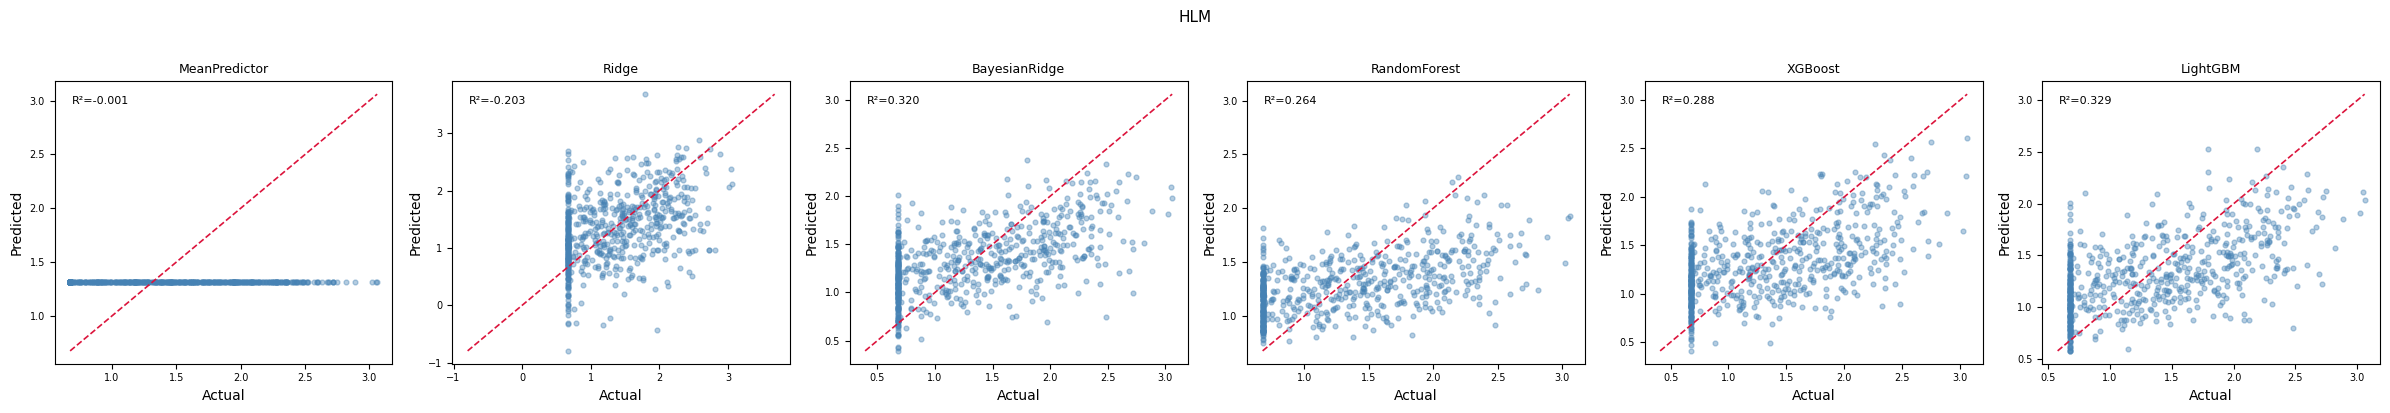

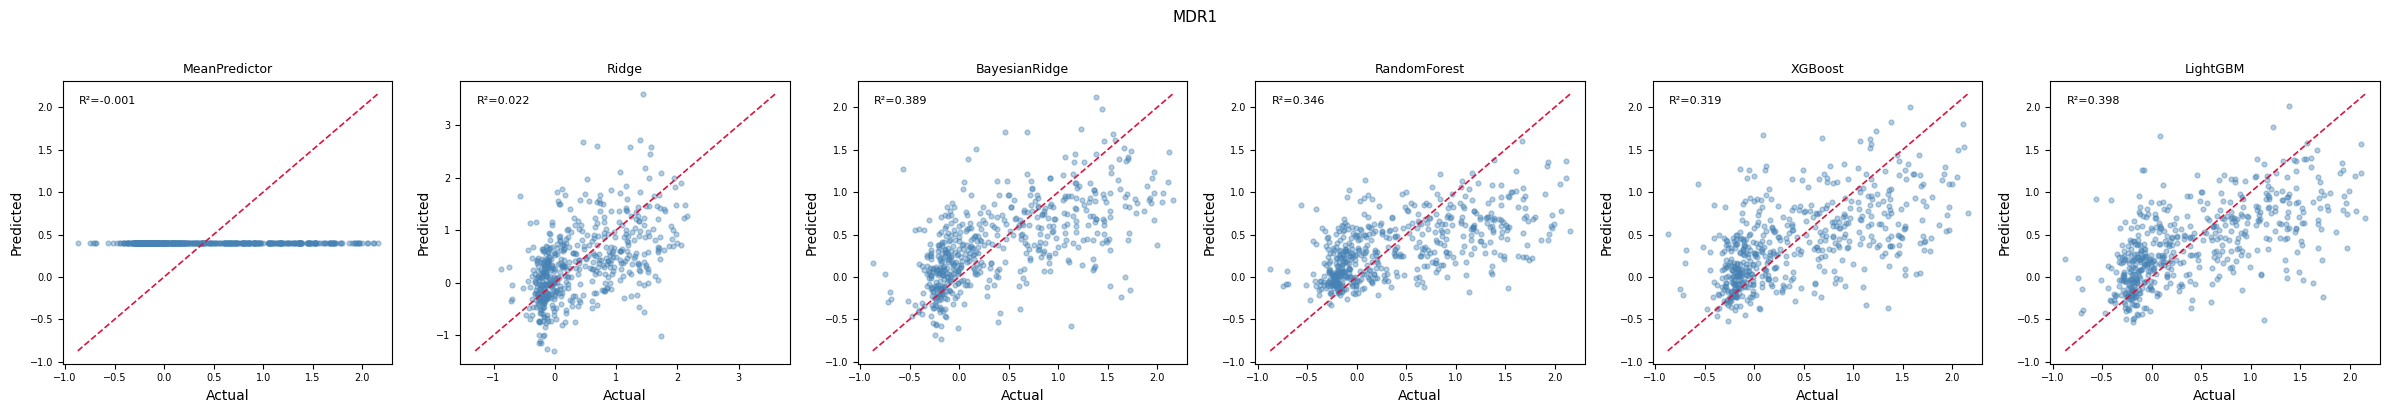

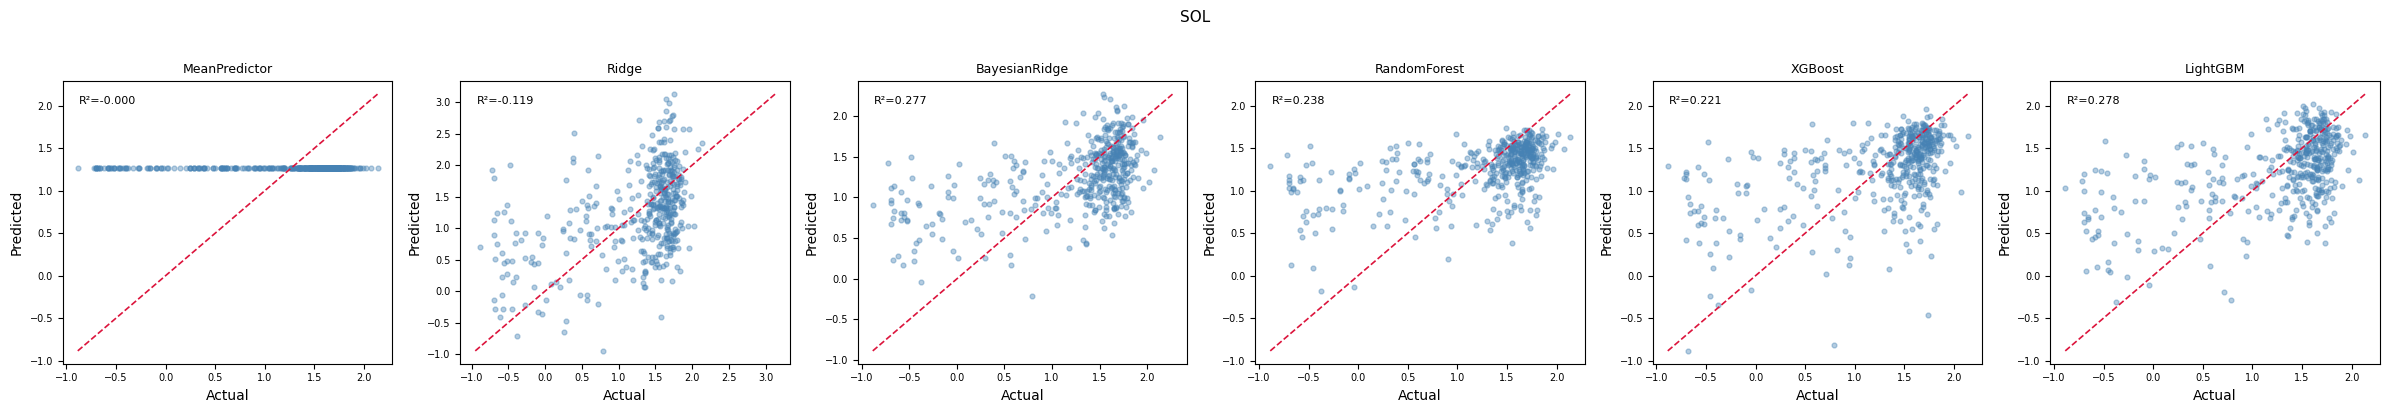

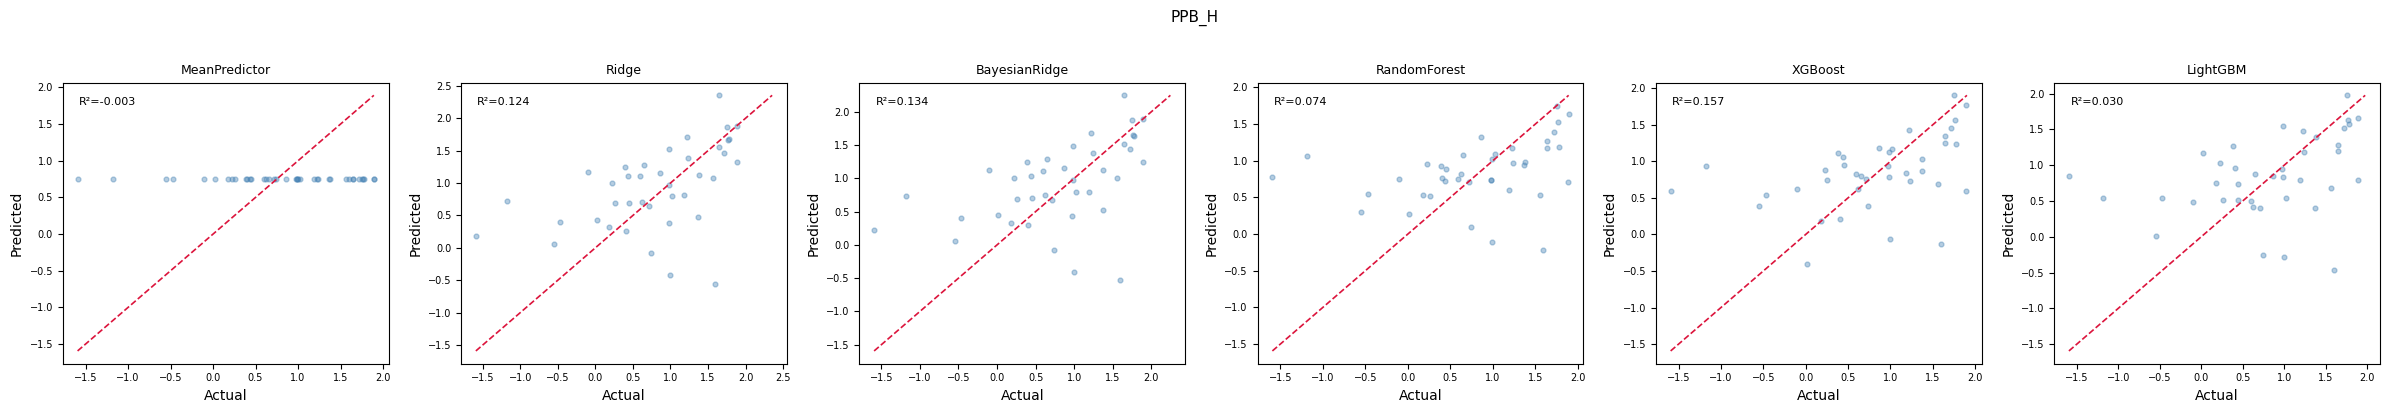

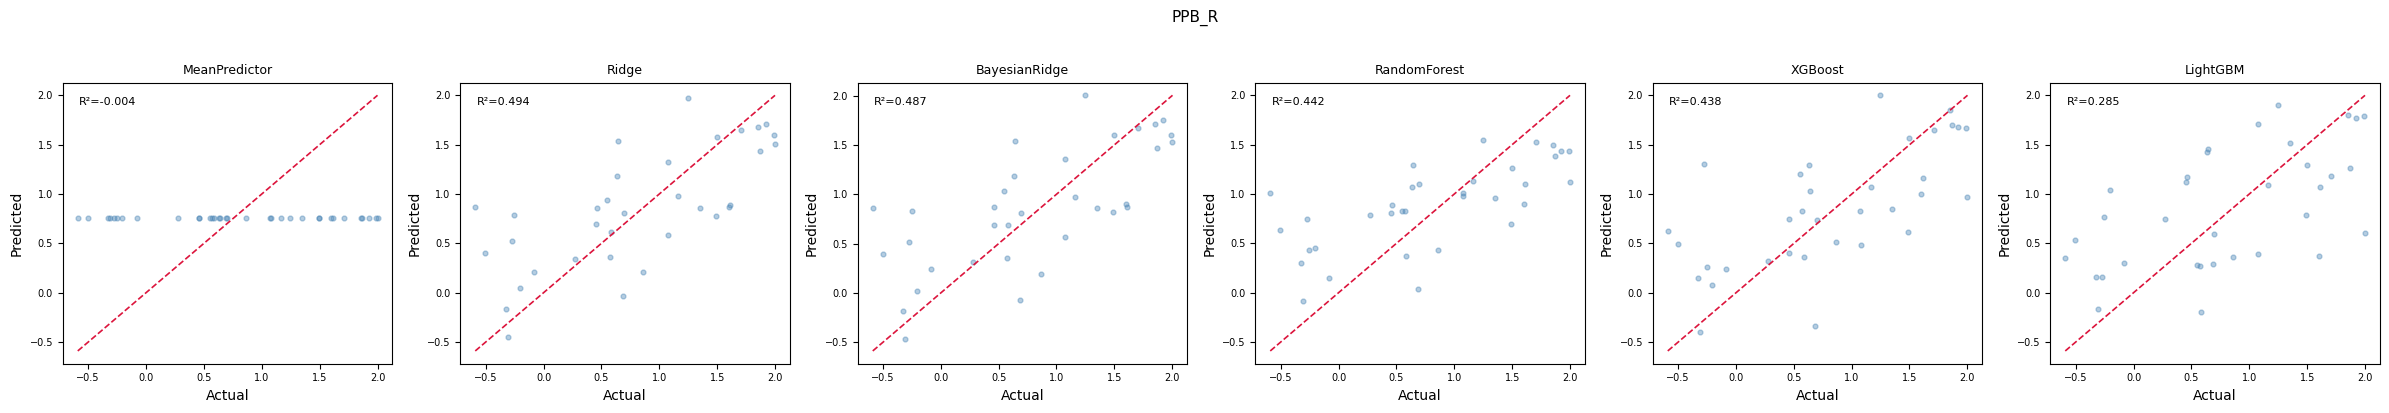

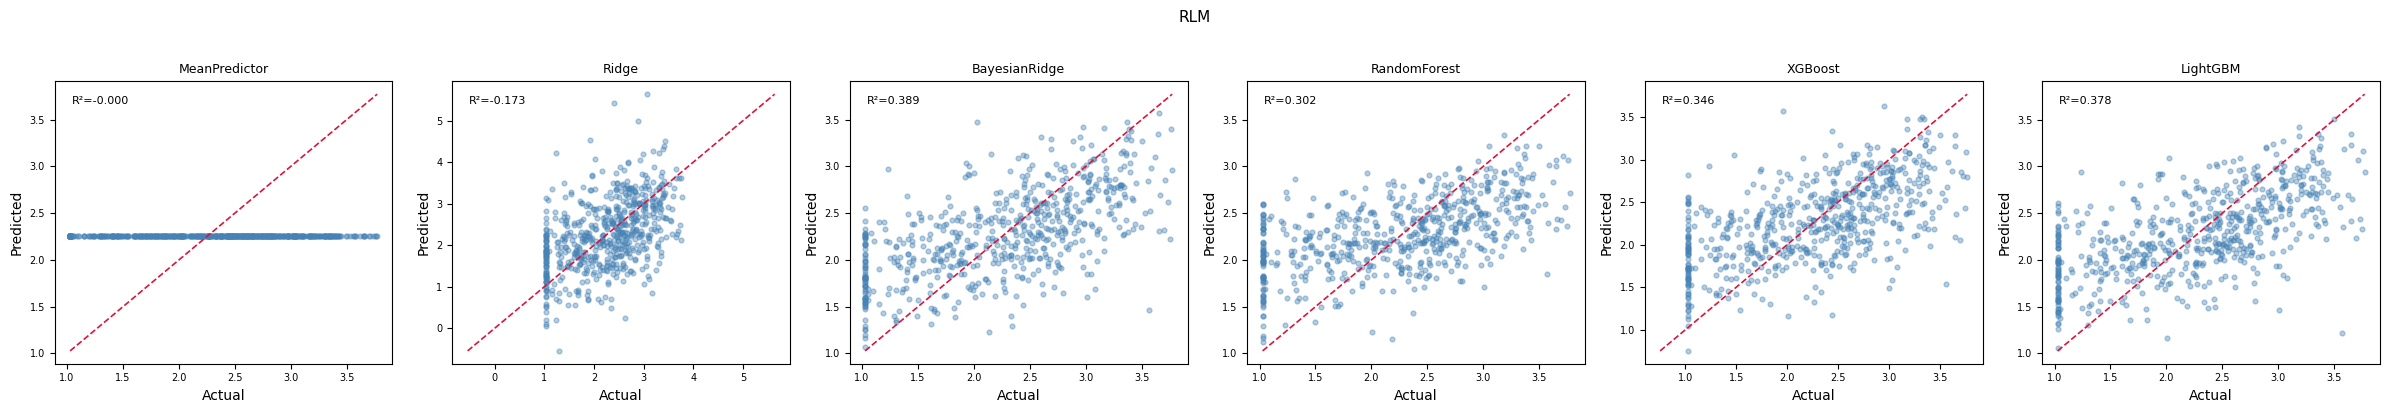

In [32]:
from src.plotting import pred_vs_actual_grid

for col in ENDPOINT_COLS:
    ep = EP_SHORT_MAP[col]
    fig = pred_vs_actual_grid(preds_store[col], title=ep)
    plt.savefig(f'../figures/2.5_pred_vs_actual_{ep}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.6 — MPNN2 (ChemProp: molecular graph + RDKit 2D descriptors)

MPNN2 - a message-passing neural network trained on the molecular graph with RDKit 2D normalised descriptors as additional features (ChemProp 1.6.1). This provides a deep learning comparison point against the sklearn baselines above.

In [33]:
if not TRAIN_MPNN2:
    print('MPNN2 training skipped (TRAIN_MPNN2=False). Set to True in the cell above to run.')
else:
    import os
    import csv
    from sklearn.metrics import r2_score, mean_squared_error as mse_fn
    from chemprop.args import TrainArgs, PredictArgs
    from chemprop.train import cross_validate, run_training, make_predictions

    MPNN2_DIR = os.path.join('..', 'models', 'mpnn2')

    def _write_csv(path, smiles_list, targets=None):
        """Write ChemProp-format CSV: smiles column + optional target column."""
        with open(path, 'w', newline='') as f:
            writer = csv.writer(f)
            if targets is not None:
                writer.writerow(['smiles', 'target'])
                for smi, y in zip(smiles_list, targets):
                    writer.writerow([smi, float(y)])
            else:
                writer.writerow(['smiles'])
                for smi in smiles_list:
                    writer.writerow([smi])

    mpnn2_results = []
    mpnn2_preds_store = {}  # {col: (y_test, y_pred)}

    for col in ENDPOINT_COLS:
        ep = EP_SHORT_MAP[col]
        _, _, y_train, y_test, smiles_train, smiles_test = splits[col]

        ep_dir    = os.path.join(MPNN2_DIR, ep)
        train_csv = os.path.join(ep_dir, 'train.csv')
        test_csv  = os.path.join(ep_dir, 'test.csv')
        preds_csv = os.path.join(ep_dir, 'preds.csv')
        os.makedirs(ep_dir, exist_ok=True)

        _write_csv(train_csv, smiles_train, y_train)
        _write_csv(test_csv,  smiles_test)

        train_args = TrainArgs().parse_args([
            '--data_path',          train_csv,
            '--dataset_type',       'regression',
            '--save_dir',           ep_dir,
            '--features_generator', 'rdkit_2d_normalized',
            '--no_features_scaling',
            '--metric',             'mae',
            '--epochs',             '30',
            '--num_folds',          '1',
            '--quiet',
        ])
        cross_validate(args=train_args, train_func=run_training)

        pred_args = PredictArgs().parse_args([
            '--test_path',          test_csv,
            '--preds_path',         preds_csv,
            '--checkpoint_dir',     ep_dir,
            '--features_generator', 'rdkit_2d_normalized',
            '--no_features_scaling',
        ])
        raw_preds = make_predictions(args=pred_args)
        y_pred = np.array([p[0] for p in raw_preds])

        mpnn2_preds_store[col] = (y_test, y_pred)

        r2   = r2_score(y_test, y_pred)
        rmse = float(np.sqrt(mse_fn(y_test, y_pred)))
        mpnn2_results.append({'endpoint': col, 'ep_short': ep, 'model': 'MPNN2', 'R2': r2, 'RMSE': rmse, 'MSE': rmse**2})
        print(f'{ep:6s}  R²={r2:+.3f}  RMSE={rmse:.3f}')

2469it [00:00, 448242.07it/s]
  0%|          | 0/2469 [00:00<?, ?it/s]/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:7087: RuntimeWarning: overflow encountered in _ncf_cdf
  return _boost._ncf_cdf(x, dfn, dfd, nc)
100%|██████████| 2469/2469 [00:00<00:00, 137287.54it/s]
Fold 0
100%|██████████| 30/30 [00:51<00:00,  1.71s/it]
Model 0 best validation mae = 0.374416 on epoch 29
Model 0 test mae = 0.359692                  
Ensemble test mae = 0.359692
1-fold cross validation
	Seed 0 ==> test mae = 0.359692
Overall test mae = 0.359692 +/- 0.000000
Elapsed time = 0:01:20


Loading training args
Setting molecule featurization parameters to default.
Loading data


618it [00:00, 354206.05it/s]
  0%|          | 0/618 [00:00<?, ?it/s]/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:7087: RuntimeWarning: overflow encountered in _ncf_cdf
  return _boost._ncf_cdf(x, dfn, dfd, nc)
100%|██████████| 618/618 [00:06<00:00, 89.15it/s]


Validating SMILES
Test size = 618


  0%|          | 0/1 [00:00<?, ?it/s]

...

Validating SMILES
Test size = 611


  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


100%|██████████| 1/1 [00:57<00:00, 57.31s/it]

Saving predictions to ../models/mpnn2/RLM/preds.csv
Elapsed time = 0:01:05
RLM     R²=+0.527  RMSE=0.512


## 2.6b — MPNN (Graph-Only, no RDKit descriptors)

Same ChemProp architecture as MPNN2 above but **without** the `rdkit_2d_normalized` auxiliary features. This isolates the learned graph representation to measure whether adding handcrafted descriptors helps the neural network.

In [34]:
if not TRAIN_MPNN_GRAPH:
    print('MPNN (graph-only) training skipped (TRAIN_MPNN_GRAPH=False). Set to True above to run.')
else:
    import os
    import csv
    from sklearn.metrics import r2_score, mean_squared_error as mse_fn
    from chemprop.args import TrainArgs, PredictArgs
    from chemprop.train import cross_validate, run_training, make_predictions

    MPNN_GRAPH_DIR = os.path.join('..', 'models', 'mpnn_graph')

    def _write_csv(path, smiles_list, targets=None):
        """Write ChemProp-format CSV: smiles column + optional target column."""
        with open(path, 'w', newline='') as f:
            writer = csv.writer(f)
            if targets is not None:
                writer.writerow(['smiles', 'target'])
                for smi, y in zip(smiles_list, targets):
                    writer.writerow([smi, float(y)])
            else:
                writer.writerow(['smiles'])
                for smi in smiles_list:
                    writer.writerow([smi])

    mpnn_graph_results = []

    for col in ENDPOINT_COLS:
        ep = EP_SHORT_MAP[col]
        _, _, y_train, y_test, smiles_train, smiles_test = splits[col]

        ep_dir    = os.path.join(MPNN_GRAPH_DIR, ep)
        train_csv = os.path.join(ep_dir, 'train.csv')
        test_csv  = os.path.join(ep_dir, 'test.csv')
        preds_csv = os.path.join(ep_dir, 'preds.csv')
        os.makedirs(ep_dir, exist_ok=True)

        _write_csv(train_csv, smiles_train, y_train)
        _write_csv(test_csv, smiles_test)

        # Graph-only: NO --features_generator, NO --no_features_scaling
        train_args = TrainArgs().parse_args([
            '--data_path',     train_csv,
            '--dataset_type',  'regression',
            '--save_dir',      ep_dir,
            '--metric',        'mae',
            '--epochs',        '30',
            '--num_folds',     '1',
            '--quiet',
        ])
        cross_validate(args=train_args, train_func=run_training)

        pred_args = PredictArgs().parse_args([
            '--test_path',      test_csv,
            '--preds_path',     preds_csv,
            '--checkpoint_dir', ep_dir,
        ])
        raw_preds = make_predictions(args=pred_args)
        y_pred = np.array([p[0] for p in raw_preds])

        r2   = r2_score(y_test, y_pred)
        rmse = np.sqrt(mse_fn(y_test, y_pred))
        print(f"  {ep:6s}  R²={r2:.3f}  RMSE={rmse:.3f}")

        mpnn_graph_results.append({
            'endpoint': col, 'ep_short': ep, 'model': 'MPNN',
            'features': 'graph', 'R2': r2, 'RMSE': rmse, 'MSE': rmse**2,
        })

    mpnn_graph_df = pd.DataFrame(mpnn_graph_results)
    print('\nMPNN (graph-only) results:')
    display(mpnn_graph_df[['ep_short', 'R2', 'RMSE']].round(3))

2469it [00:00, 464174.66it/s]
100%|██████████| 2469/2469 [00:00<00:00, 98132.60it/s]
Fold 0
100%|██████████| 30/30 [01:08<00:00,  2.28s/it]
Model 0 best validation mae = 0.389862 on epoch 29
Model 0 test mae = 0.381428                  
Ensemble test mae = 0.381428
1-fold cross validation
	Seed 0 ==> test mae = 0.381428
Overall test mae = 0.381428 +/- 0.000000
Elapsed time = 0:01:09


Loading training args
Setting molecule featurization parameters to default.
Loading data


618it [00:00, 42221.79it/s]
100%|██████████| 618/618 [00:00<00:00, 51676.23it/s]


Validating SMILES
Test size = 618


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


100%|██████████| 1/1 [00:48<00:00, 48.72s/it]

Saving predictions to ../models/mpnn_graph/RLM/preds.csv
Elapsed time = 0:00:49
  RLM     R²=0.485  RMSE=0.535

MPNN (graph-only) results:


,ep_short,R2,RMSE
0,HLM,0.4090,0.4760
1,MDR1,0.4010,0.5210
2,SOL,0.2430,0.5980
3,PPB_H,-0.0650,0.8460
4,PPB_R,0.0230,0.7800
5,RLM,0.4850,0.5350


In [35]:
col_order_base = ['MeanPredictor', 'Ridge', 'BayesianRidge', 'RandomForest', 'XGBoost', 'LightGBM']
mpnn_cols = (['MPNN2'] if TRAIN_MPNN2 else []) + (['MPNN'] if TRAIN_MPNN_GRAPH else [])

for feat in results_df['features'].unique():
    subset = results_df[results_df['features'] == feat].copy()

    if TRAIN_MPNN2:
        subset = pd.concat([subset, pd.DataFrame(mpnn2_results)], ignore_index=True)
    if TRAIN_MPNN_GRAPH:
        subset = pd.concat([subset, mpnn_graph_df], ignore_index=True)

    col_order = [c for c in col_order_base + mpnn_cols if c in subset['model'].values]

    print(f'R² (test set) — {feat} + deep learning if included as part of training:')
    display(subset.pivot(index='ep_short', columns='model', values='R2').round(3)[col_order])

    print(f'\nRMSE (test set) — {feat} + deep learning if included as part of training:')
    display(subset.pivot(index='ep_short', columns='model', values='RMSE').round(3)[col_order])
    print()

R² (test set) — ECFP4 + deep learning if included as part of training:


model,MeanPredictor,Ridge,BayesianRidge,RandomForest,XGBoost,LightGBM,MPNN2,MPNN
ep_short,,,,,,,,
HLM,-0.0010,-0.2030,0.3200,0.2640,0.2880,0.3290,0.4900,0.4090
MDR1,-0.0010,0.0220,0.3890,0.3460,0.3190,0.3980,0.5300,0.4010
PPB_H,-0.0030,0.1240,0.1340,0.0740,0.1570,0.0300,-0.2540,-0.0650
PPB_R,-0.0040,0.4940,0.4870,0.4420,0.4380,0.2850,0.5130,0.0230
RLM,-0.0000,-0.1730,0.3890,0.3020,0.3460,0.3780,0.5270,0.4850
SOL,-0.0000,-0.1190,0.2770,0.2380,0.2210,0.2780,0.3170,0.2430



RMSE (test set) — ECFP4 + deep learning if included as part of training:


model,MeanPredictor,Ridge,BayesianRidge,RandomForest,XGBoost,LightGBM,MPNN2,MPNN
ep_short,,,,,,,,
HLM,0.6200,0.6800,0.5110,0.5320,0.5230,0.5080,0.4430,0.4760
MDR1,0.6740,0.6660,0.5270,0.5450,0.5560,0.5220,0.4620,0.5210
PPB_H,0.8210,0.7670,0.7630,0.7890,0.7530,0.8070,0.9180,0.8460
PPB_R,0.7910,0.5610,0.5650,0.5900,0.5920,0.6670,0.5510,0.7800
RLM,0.7450,0.8070,0.5830,0.6230,0.6030,0.5880,0.5120,0.5350
SOL,0.6870,0.7270,0.5840,0.6000,0.6060,0.5840,0.5680,0.5980



R² (test set) — RDKit2D + deep learning if included as part of training:


model,MeanPredictor,Ridge,BayesianRidge,RandomForest,XGBoost,LightGBM,MPNN2,MPNN
ep_short,,,,,,,,
HLM,-0.0010,0.3820,0.3780,0.4060,0.4300,0.4810,0.4900,0.4090
MDR1,-0.0010,0.4850,0.4770,0.4500,0.4280,0.5070,0.5300,0.4010
PPB_H,-0.0030,0.2930,0.3660,0.3090,0.2730,0.3310,-0.2540,-0.0650
PPB_R,-0.0040,0.3860,0.6020,0.5830,0.4100,0.5540,0.5130,0.0230
RLM,-0.0000,0.3620,0.3640,0.4460,0.4380,0.4770,0.5270,0.4850
SOL,-0.0000,0.1980,0.2390,0.2450,0.1390,0.2410,0.3170,0.2430



RMSE (test set) — RDKit2D + deep learning if included as part of training:


model,MeanPredictor,Ridge,BayesianRidge,RandomForest,XGBoost,LightGBM,MPNN2,MPNN
ep_short,,,,,,,,
HLM,0.6200,0.4870,0.4890,0.4780,0.4680,0.4470,0.4430,0.4760
MDR1,0.6740,0.4830,0.4870,0.4990,0.5090,0.4730,0.4620,0.5210
PPB_H,0.8210,0.6890,0.6530,0.6820,0.6990,0.6700,0.9180,0.8460
PPB_R,0.7910,0.6180,0.4980,0.5100,0.6060,0.5270,0.5510,0.7800
RLM,0.7450,0.5950,0.5940,0.5550,0.5590,0.5390,0.5120,0.5350
SOL,0.6870,0.6150,0.5990,0.5970,0.6380,0.5990,0.5680,0.5980


## 2.7 — Similarity-Binned Prediction Error (Sørensen–Dice / FCFP, radius=4)

For each test compound, compute the mean Sørensen–Dice similarity to the top-5 nearest training neighbours using FCFP4 fingerprints (radius=4, 1024 bits), then bin test compounds by similarity and plot MAE per bin. This follows the methodology of Fang et al. to assess whether models perform worse on compounds that are structurally distant from the training set.

In [36]:
from rdkit.Chem import AllChem
from rdkit import DataStructs

def _fcfp4_fps(smiles_list, n_bits=1024):
    """Compute FCFP fingerprints (feature-class Morgan, radius=4, 1024-bit) as RDKit ExplicitBitVect objects."""
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            raise ValueError(f"Invalid SMILES: {smi!r}")
        fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits, useFeatures=True))
    return fps

TOP_K = 5  # mean of top-5 similarity, as per Fang et al.

sim_records = []

for col in ENDPOINT_COLS:
    _, _, _, _, smiles_train, smiles_test = splits[col]

    train_fps = _fcfp4_fps(smiles_train)
    test_fps  = _fcfp4_fps(smiles_test)

    mean_top5_sims = np.array([
        np.mean(sorted(DataStructs.BulkDiceSimilarity(fp, train_fps), reverse=True)[:TOP_K])
        for fp in test_fps
    ])
    sim_bins = np.clip(np.floor(mean_top5_sims * 10) / 10, 0.0, 0.9)

    # Baseline models
    for model_name, (y_test, y_pred) in preds_store[col].items():
        abs_errors = np.abs(y_test - y_pred)
        for sim_bin, abs_err in zip(sim_bins, abs_errors):
            sim_records.append({'ep_short': EP_SHORT_MAP[col], 'model': model_name,
                                 'sim_bin': sim_bin, 'abs_error': abs_err})

    # MPNN2 — included only if training was run
    if TRAIN_MPNN2:
        y_test_m, y_pred_m = mpnn2_preds_store[col]
        abs_errors = np.abs(y_test_m - y_pred_m)
        for sim_bin, abs_err in zip(sim_bins, abs_errors):
            sim_records.append({'ep_short': EP_SHORT_MAP[col], 'model': 'MPNN2',
                                 'sim_bin': sim_bin, 'abs_error': abs_err})

sim_df = pd.DataFrame(sim_records)
print(f'Records: {len(sim_df)}')
print(f"Models in sim_df: {sorted(sim_df['model'].unique())}")
print(f"Similarity bin distribution:\n{sim_df['sim_bin'].value_counts().sort_index().to_string()}")

Records: 15862
Models in sim_df: ['BayesianRidge', 'LightGBM', 'MPNN2', 'MeanPredictor', 'RandomForest', 'Ridge', 'XGBoost']
Similarity bin distribution:
sim_bin
0.2000     119
0.3000    4200
0.4000    7966
0.5000    2758
0.6000     658
0.7000     119
0.8000      42


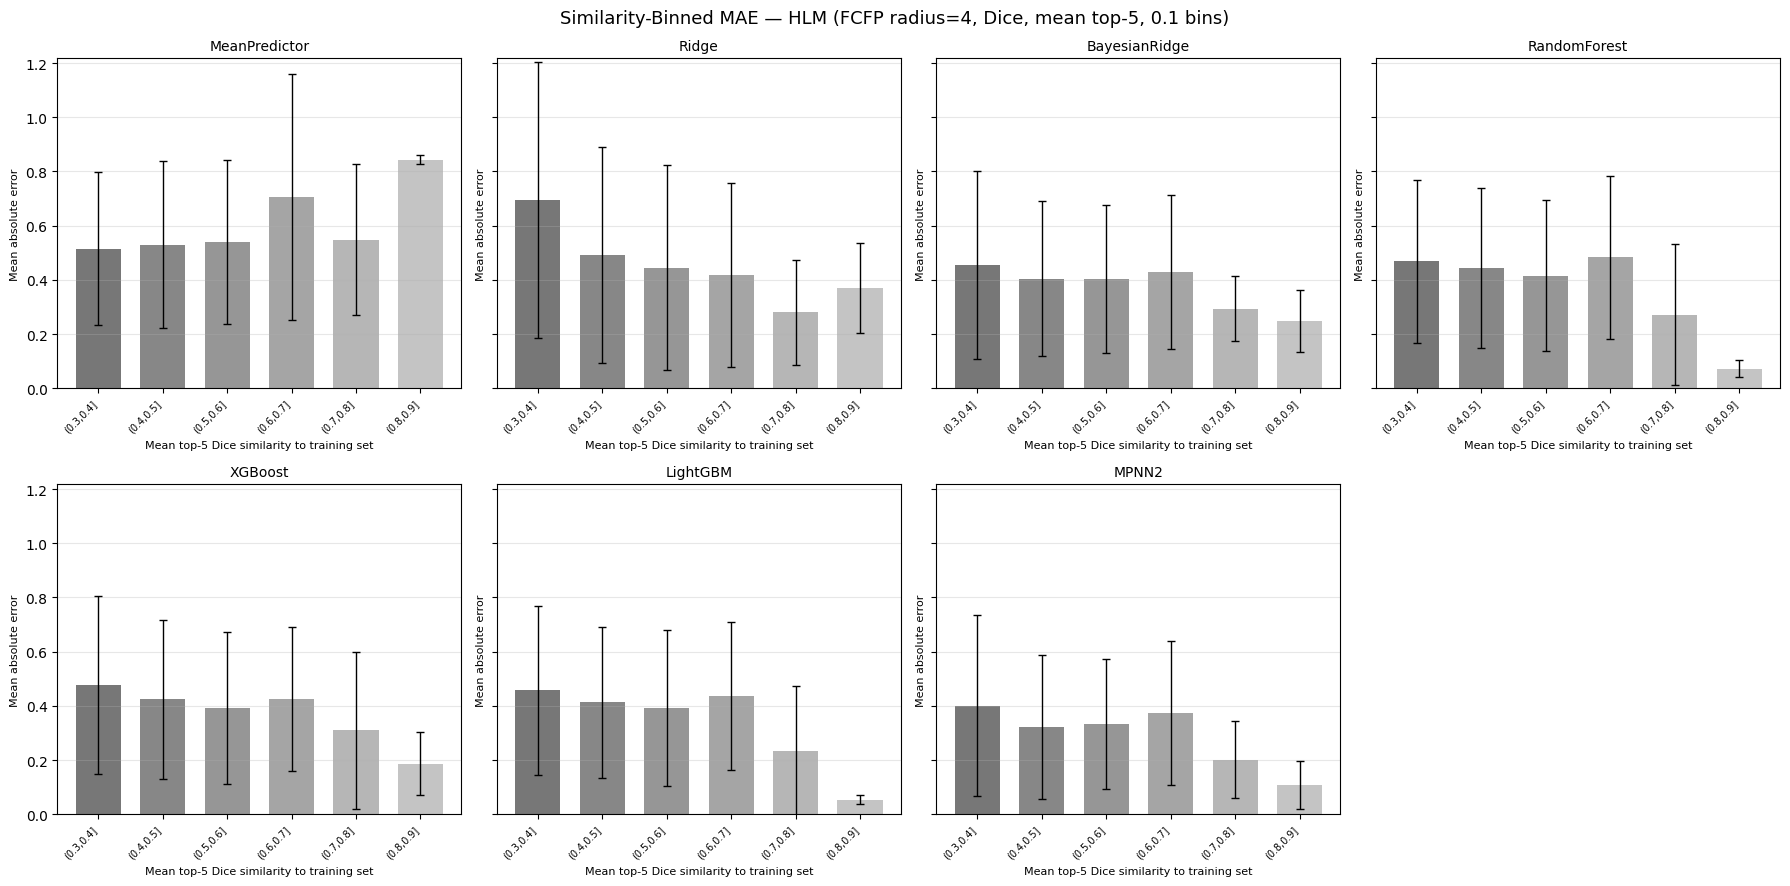

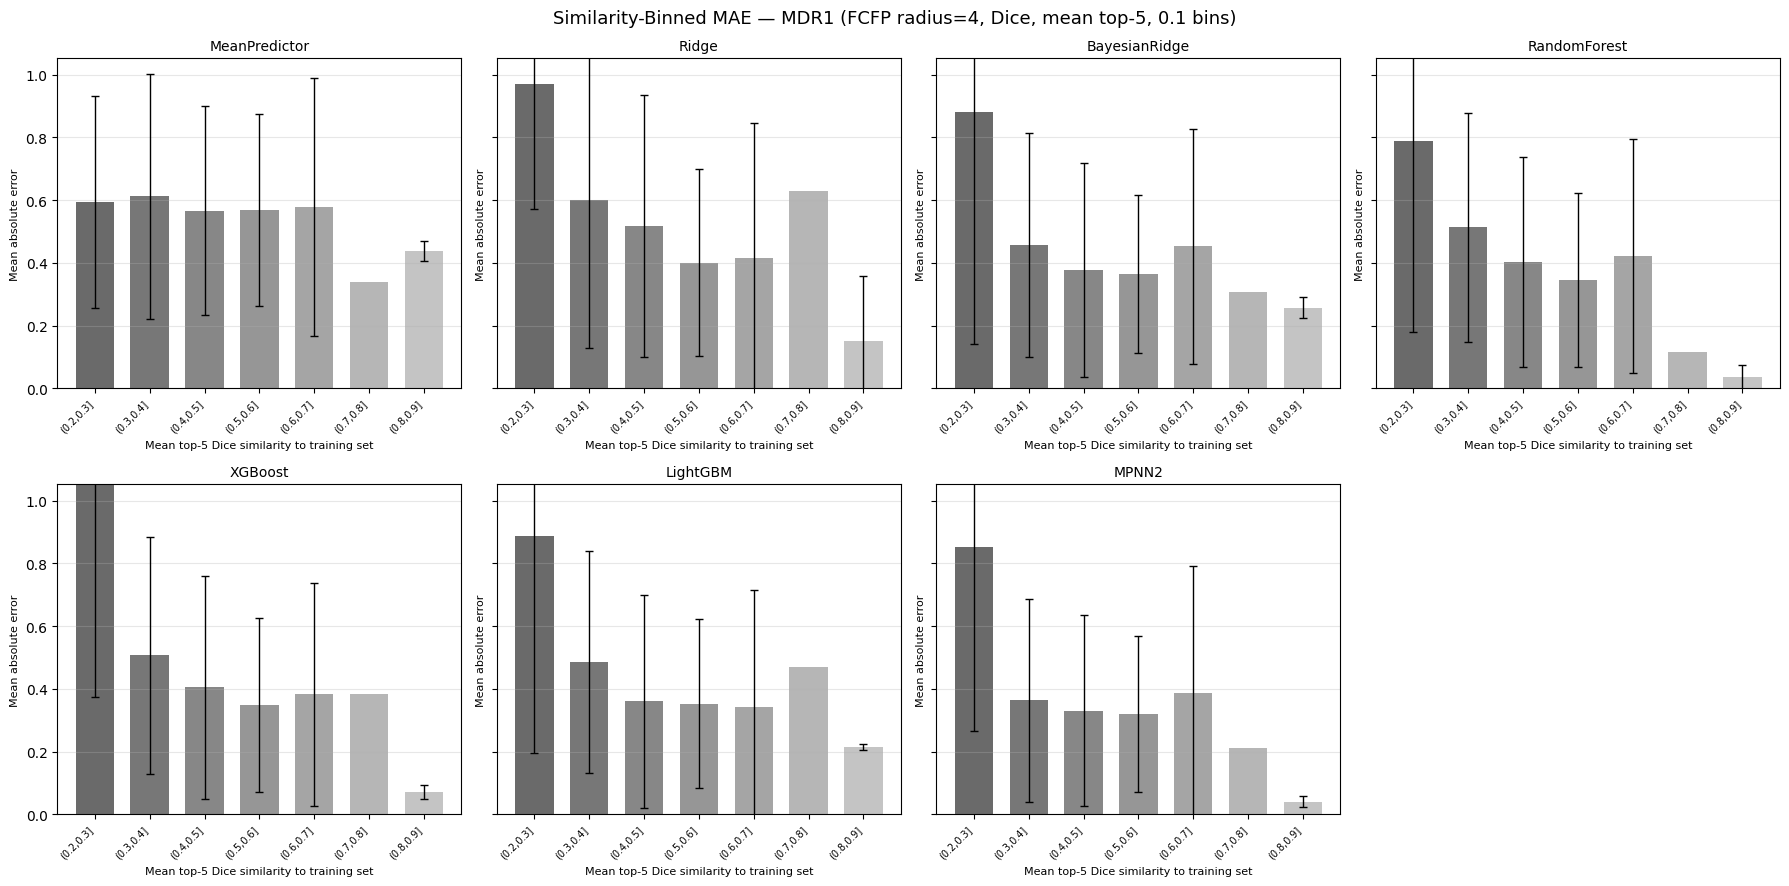

In [37]:
model_names = ['MeanPredictor', 'Ridge', 'BayesianRidge', 'RandomForest', 'XGBoost', 'LightGBM', 'MPNN2']
present_models = [m for m in model_names if m in sim_df['model'].unique()]
focus_eps   = ['HLM', 'MDR1']

bins       = np.arange(0.0, 1.0, 0.1)
bar_width  = 0.04
bar_colors = plt.cm.Greys(np.linspace(0.8, 0.3, len(bins)))

for ep in focus_eps:
    ep_df = sim_df[sim_df['ep_short'] == ep]
    n_models = len(present_models)
    fig, axes = plt.subplots(2, 4 if n_models > 6 else 3, figsize=(18 if n_models > 6 else 16, 9), sharey=True)
    axes = axes.flatten()

    for ax, model in zip(axes, present_models):
        m_df = ep_df[ep_df['model'] == model]
        stats = m_df.groupby('sim_bin')['abs_error'].agg(['mean', 'std', 'count'])

        for j, (sim_bin, row) in enumerate(stats.iterrows()):
            ax.bar(j, row['mean'], color=bar_colors[int(round(sim_bin * 10))],
                   width=0.7, alpha=0.95)
            ax.errorbar(j, row['mean'], yerr=row['std'], fmt='none',
                        color='black', capsize=3, linewidth=1)

        ax.set_title(model, fontsize=10)
        ax.set_xlabel('Mean top-5 Dice similarity to training set', fontsize=8)
        ax.set_ylabel('Mean absolute error', fontsize=8)
        ax.set_xticks(range(len(stats)))
        ax.set_xticklabels([f'({b:.1f},{b+0.1:.1f}]' for b in stats.index],
                           rotation=45, ha='right', fontsize=7)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3, axis='y')

    for ax in axes[n_models:]:
        ax.set_visible(False)

    fig.suptitle(f'Similarity-Binned MAE — {ep} (FCFP radius=4, Dice, mean top-5, 0.1 bins)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'../figures/2.7_sim_binned_mae_{ep}.png', dpi=150, bbox_inches='tight')
    plt.show()

---

# Part 3 — Hyperparameter Tuning (Clean-Data Reference)

Tune LightGBM, RandomForest, and MPNN2 on each endpoint's **full, clean** training set. This serves two purposes:

1. **Validate the tuning pipeline** — confirm that RandomizedSearchCV and early stopping work correctly before the experiment loop.
2. **Establish a clean-data ceiling** — the best R² achievable with tuned hyperparameters on clean, full data. Phases 4–6 will show how performance degrades from this ceiling.

In Phases 4–6, tuning is **re-run per condition** (the tuned arm), alongside a baseline arm using default hyperparameters. This shows whether tuning buys resilience under degraded data conditions.

**Endpoints**: HLM, MDR1, SOL, RLM (4 modelling endpoints — PPB excluded, too sparse for CV-based tuning).

**CV scoring**: MAE (`neg_mean_absolute_error`) — less sensitive to noisy labels than RMSE, important for the noise injection experiments in Phase 5.

**MPNN2**: Fixed architecture + early stopping with MAE metric (controlled by `TUNE_MPNN2` flag).

## 3.1 — LightGBM Hyperparameter Tuning

In [38]:
import os
from sklearn.model_selection import train_test_split
from src.tuning import tune_lightgbm, tune_rf, save_params, load_params, make_model
from src.models import evaluate_model

TUNED_PARAMS_DIR = os.path.join('..', 'models', 'tuned_params')
os.makedirs(TUNED_PARAMS_DIR, exist_ok=True)

# Focus modelling on 4 endpoints with sufficient data
MODEL_ENDPOINTS = [
    'LOG HLM_CLint (mL/min/kg)',
    'LOG MDR1-MDCK ER (B-A/A-B)',
    'LOG SOLUBILITY PH 6.8 (ug/mL)',
    'LOG RLM_CLint (mL/min/kg)',
]

lgbm_tuned_results = []

for col in MODEL_ENDPOINTS:
    ep = EP_SHORT_MAP[col]
    X_train, X_test, y_train, y_test, _, _ = splits_rdkit[col]

    # Hold out 20% of train as a fixed validation set for hyperparameter selection
    X_train_tune, X_val, y_train_tune, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=SEED
    )

    model, params = tune_lightgbm(X_train_tune, y_train_tune, X_val, y_val, n_iter=50, random_state=SEED)
    save_params(params, os.path.join(TUNED_PARAMS_DIR, f'{ep}_lgbm.json'))

    metrics = evaluate_model(model, X_test, y_test)
    lgbm_tuned_results.append({'ep_short': ep, 'model': 'LightGBM (tuned)', **metrics})
    print(f'{ep:6s}  R²={metrics["R2"]:+.3f}  RMSE={metrics["RMSE"]:.3f}  params={params}')

lgbm_tuned_df = pd.DataFrame(lgbm_tuned_results)

HLM     R²=+0.470  RMSE=0.451  params={'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 50, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
MDR1    R²=+0.506  RMSE=0.473  params={'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
SOL     R²=+0.260  RMSE=0.591  params={'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
RLM     R²=+0.485  RMSE=0.535  params={'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


## 3.1b — Random Forest Hyperparameter Tuning

In [39]:
rf_tuned_results = []

for col in MODEL_ENDPOINTS:
    ep = EP_SHORT_MAP[col]
    X_train, X_test, y_train, y_test, _, _ = splits_rdkit[col]

    # Hold out 20% of train as a fixed validation set for hyperparameter selection
    X_train_tune, X_val, y_train_tune, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=SEED
    )

    model, params = tune_rf(X_train_tune, y_train_tune, X_val, y_val, n_iter=50, random_state=SEED)
    save_params(params, os.path.join(TUNED_PARAMS_DIR, f'{ep}_rf.json'))

    metrics = evaluate_model(model, X_test, y_test)
    rf_tuned_results.append({'ep_short': ep, 'model': 'RandomForest (tuned)', **metrics})
    print(f'{ep:6s}  R²={metrics["R2"]:+.3f}  RMSE={metrics["RMSE"]:.3f}  params={params}')

rf_tuned_df = pd.DataFrame(rf_tuned_results)

HLM     R²=+0.409  RMSE=0.476  params={'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 30}
MDR1    R²=+0.451  RMSE=0.499  params={'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}
SOL     R²=+0.268  RMSE=0.588  params={'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': None}
RLM     R²=+0.427  RMSE=0.564  params={'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}


In [40]:
# Compare baseline vs tuned for both LightGBM and RF (4 endpoints)
# Filter to RDKit2D only — tuning was performed on RDKit2D features
baseline = results_df[
    (results_df['features'] == 'RDKit2D') &
    (results_df['model'].isin(['LightGBM', 'RandomForest'])) &
    (results_df['ep_short'].isin(['HLM', 'MDR1', 'SOL', 'RLM']))
][['ep_short', 'model', 'R2', 'RMSE']].copy()

tuned = pd.concat([lgbm_tuned_df, rf_tuned_df])[['ep_short', 'model', 'R2', 'RMSE']]
all_compare = pd.concat([baseline, tuned], ignore_index=True)

print('R² — Baseline vs Tuned:')
r2_pivot = all_compare.pivot(index='ep_short', columns='model', values='R2')[
    ['RandomForest', 'RandomForest (tuned)', 'LightGBM', 'LightGBM (tuned)']
].round(4)
display(r2_pivot)

print('\nRMSE — Baseline vs Tuned:')
rmse_pivot = all_compare.pivot(index='ep_short', columns='model', values='RMSE')[
    ['RandomForest', 'RandomForest (tuned)', 'LightGBM', 'LightGBM (tuned)']
].round(4)
display(rmse_pivot)

R² — Baseline vs Tuned:


model,RandomForest,RandomForest (tuned),LightGBM,LightGBM (tuned)
ep_short,,,,
HLM,0.4058,0.4092,0.4809,0.4700
MDR1,0.4500,0.4511,0.5067,0.5063
RLM,0.4456,0.4274,0.4772,0.4853
SOL,0.2446,0.2680,0.2409,0.2605



RMSE — Baseline vs Tuned:


model,RandomForest,RandomForest (tuned),LightGBM,LightGBM (tuned)
ep_short,,,,
HLM,0.4779,0.4765,0.4466,0.4513
MDR1,0.4995,0.4990,0.4731,0.4732
RLM,0.5550,0.5640,0.5389,0.5347
SOL,0.5972,0.5878,0.5987,0.5909


## 3.2 — MPNN2 Tuning (Early Stopping)

ChemProp's built-in early stopping handles tuning: fixed architecture (`hidden_size=300, depth=3`, ChemProp defaults), generous `--epochs 50`. The internal train/val split stops training when validation RMSE plateaus. Large endpoints only (HLM, MDR1, RLM, SOL; ≥500 training rows).

Set `TUNE_MPNN2 = True` to run in the first cell of the notebook

In [41]:
if not TUNE_MPNN2:
    print('MPNN2 tuning skipped (TUNE_MPNN2=False). Set to True to run.')
else:
    import csv
    from chemprop.args import TrainArgs, PredictArgs
    from chemprop.train import cross_validate, run_training, make_predictions
    from sklearn.metrics import r2_score, mean_squared_error as mse_fn

    LARGE_ENDPOINTS = [
        'LOG HLM_CLint (mL/min/kg)',
        'LOG MDR1-MDCK ER (B-A/A-B)',
        'LOG SOLUBILITY PH 6.8 (ug/mL)',
        'LOG RLM_CLint (mL/min/kg)',
    ]

    MPNN2_TUNE_DIR = os.path.join('..', 'models', 'mpnn2_tuned')
    MPNN2_CONFIG = {'hidden_size': 300, 'depth': 3, 'epochs': 50}

    def _write_csv(path, smiles_list, targets=None):
        with open(path, 'w', newline='') as f:
            writer = csv.writer(f)
            if targets is not None:
                writer.writerow(['smiles', 'target'])
                for smi, y in zip(smiles_list, targets):
                    writer.writerow([smi, float(y)])
            else:
                writer.writerow(['smiles'])
                for smi in smiles_list:
                    writer.writerow([smi])

    mpnn2_tuned_results = []

    for col in LARGE_ENDPOINTS:
        ep = EP_SHORT_MAP[col]
        _, _, y_train, y_test, smiles_train, smiles_test = splits[col]

        ep_dir    = os.path.join(MPNN2_TUNE_DIR, ep)
        train_csv = os.path.join(ep_dir, 'train.csv')
        test_csv  = os.path.join(ep_dir, 'test.csv')
        preds_csv = os.path.join(ep_dir, 'preds.csv')
        os.makedirs(ep_dir, exist_ok=True)
        _write_csv(train_csv, smiles_train, y_train)
        _write_csv(test_csv,  smiles_test)

        train_args = TrainArgs().parse_args([
            '--data_path',          train_csv,
            '--dataset_type',       'regression',
            '--save_dir',           ep_dir,
            '--features_generator', 'rdkit_2d_normalized',
            '--no_features_scaling',
            '--metric',             'mae',
            '--epochs',             str(MPNN2_CONFIG['epochs']),
            '--hidden_size',        str(MPNN2_CONFIG['hidden_size']),
            '--depth',              str(MPNN2_CONFIG['depth']),
            '--num_folds',          '1',
            '--quiet',
        ])
        cross_validate(args=train_args, train_func=run_training)

        pred_args = PredictArgs().parse_args([
            '--test_path',          test_csv,
            '--preds_path',         preds_csv,
            '--checkpoint_dir',     ep_dir,
            '--features_generator', 'rdkit_2d_normalized',
            '--no_features_scaling',
        ])
        raw_preds = make_predictions(args=pred_args)
        y_pred = np.array([p[0] for p in raw_preds])

        r2   = r2_score(y_test, y_pred)
        rmse = float(np.sqrt(mse_fn(y_test, y_pred)))
        mpnn2_tuned_results.append({'ep_short': ep, 'model': 'MPNN2 (tuned)', 'R2': r2, 'RMSE': rmse})
        print(f'{ep:6s}  R²={r2:+.3f}  RMSE={rmse:.3f}')

    # Save config for documentation
    save_params(MPNN2_CONFIG, os.path.join(TUNED_PARAMS_DIR, 'mpnn2_config.json'))
    mpnn2_tuned_df = pd.DataFrame(mpnn2_tuned_results)

2469it [00:00, 711538.86it/s]
  0%|          | 0/2469 [00:00<?, ?it/s]/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:7087: RuntimeWarning: overflow encountered in _ncf_cdf
  return _boost._ncf_cdf(x, dfn, dfd, nc)
100%|██████████| 2469/2469 [00:00<00:00, 265858.92it/s]
Fold 0
100%|██████████| 50/50 [01:29<00:00,  1.78s/it]
Model 0 best validation mae = 0.357936 on epoch 35
Model 0 test mae = 0.355999                  
Ensemble test mae = 0.355999
1-fold cross validation
	Seed 0 ==> test mae = 0.355999
Overall test mae = 0.355999 +/- 0.000000
Elapsed time = 0:01:57


Loading training args
Setting molecule featurization parameters to default.
Loading data


618it [00:00, 312562.39it/s]
  0%|          | 0/618 [00:00<?, ?it/s]/Users/zarif/Documents/Projects/uniq-plus-data-quantity-noise-qsar/.venv/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:7087: RuntimeWarning: overflow encountered in _ncf_cdf
  return _boost._ncf_cdf(x, dfn, dfd, nc)
100%|██████████| 618/618 [00:07<00:00, 87.29it/s]


Validating SMILES
Test size = 618


  0%|          | 0/1 [00:00<?, ?it/s]

...

Validating SMILES
Test size = 611


  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


100%|██████████| 1/1 [00:54<00:00, 54.66s/it]

Saving predictions to ../models/mpnn2_tuned/RLM/preds.csv
Elapsed time = 0:01:02
RLM     R²=+0.516  RMSE=0.518


### 3.3 Re-evaluate with full metric set (MAE, Spearman ρ, CCC)

`evaluate_model` was extended after the tuning cells ran. This cell reloads the updated module, refits LightGBM and RF from their saved param JSONs (fast — no RandomizedSearchCV), and loads MPNN2 predictions from the saved `preds.csv`. Results are persisted to CSV.

In [42]:

# ── 3.3  Re-evaluate tuned models with full metric set ──────────────────────
# evaluate_model was updated after tuning ran (added MAE, Spearman, CCC).
# Must reload the submodule (src.models.models) before the package to pick up changes.

import importlib
import src.models.models as _models_submod
importlib.reload(_models_submod)
import src.models as _models_mod
importlib.reload(_models_mod)
from src.models.models import evaluate_model

lgbm_reeval, rf_reeval, mpnn2_reeval = [], [], []

for col in MODEL_ENDPOINTS:
    ep = EP_SHORT_MAP[col]
    X_train, X_test, y_train, y_test, smiles_train, smiles_test = splits_rdkit[col]

    # LightGBM — load best params, refit on full training set (seconds)
    lgbm_params = load_params(os.path.join(TUNED_PARAMS_DIR, f'{ep}_lgbm.json'))
    lgbm_model = make_model('LightGBM', lgbm_params).fit(X_train, y_train)
    m = evaluate_model(lgbm_model, X_test, y_test)
    lgbm_reeval.append({'ep_short': ep, 'model': 'LightGBM (tuned)', **m})
    print(f'LightGBM  {ep:6s}  R²={m["R2"]:+.3f}  RMSE={m["RMSE"]:.3f}  MAE={m["MAE"]:.3f}  ρ={m["Spearman"]:.3f}  CCC={m["CCC"]:.3f}')

    # RandomForest — same pattern
    rf_params = load_params(os.path.join(TUNED_PARAMS_DIR, f'{ep}_rf.json'))
    rf_model = make_model('RandomForest', rf_params).fit(X_train, y_train)
    m = evaluate_model(rf_model, X_test, y_test)
    rf_reeval.append({'ep_short': ep, 'model': 'RandomForest (tuned)', **m})
    print(f'RF        {ep:6s}  R²={m["R2"]:+.3f}  RMSE={m["RMSE"]:.3f}  MAE={m["MAE"]:.3f}  ρ={m["Spearman"]:.3f}  CCC={m["CCC"]:.3f}')

    # MPNN2 — load predictions from saved preds.csv (no retraining needed)
    # y_test is identical between splits and splits_rdkit (same random_state)
    preds_csv = os.path.join('..', 'models', 'mpnn2_tuned', ep, 'preds.csv')
    if os.path.exists(preds_csv):
        y_pred_mpnn2 = pd.read_csv(preds_csv).iloc[:, 1].values
        m = evaluate_model(None, None, y_test, y_pred=y_pred_mpnn2)
        mpnn2_reeval.append({'ep_short': ep, 'model': 'MPNN2 (tuned)', **m})
        print(f'MPNN2     {ep:6s}  R²={m["R2"]:+.3f}  RMSE={m["RMSE"]:.3f}  MAE={m["MAE"]:.3f}  ρ={m["Spearman"]:.3f}  CCC={m["CCC"]:.3f}')

    print()

# Overwrite in-memory DataFrames with full-metric versions
lgbm_tuned_df = pd.DataFrame(lgbm_reeval)
rf_tuned_df   = pd.DataFrame(rf_reeval)

lgbm_tuned_df.to_csv(os.path.join(TUNED_PARAMS_DIR, 'lgbm_tuned_metrics.csv'), index=False)
rf_tuned_df.to_csv(  os.path.join(TUNED_PARAMS_DIR, 'rf_tuned_metrics.csv'),   index=False)

if mpnn2_reeval:
    mpnn2_tuned_df = pd.DataFrame(mpnn2_reeval)
    mpnn2_tuned_df.to_csv(os.path.join(TUNED_PARAMS_DIR, 'mpnn2_tuned_metrics.csv'), index=False)

print('Metrics saved to', TUNED_PARAMS_DIR)

LightGBM  HLM     R²=+0.469  RMSE=0.452  MAE=0.357  ρ=0.685  CCC=0.649
RF        HLM     R²=+0.404  RMSE=0.479  MAE=0.390  ρ=0.646  CCC=0.542
MPNN2     HLM     R²=+0.488  RMSE=0.443  MAE=0.339  ρ=0.716  CCC=0.699

LightGBM  MDR1    R²=+0.501  RMSE=0.476  MAE=0.347  ρ=0.722  CCC=0.670
RF        MDR1    R²=+0.455  RMSE=0.497  MAE=0.384  ρ=0.686  CCC=0.603
MPNN2     MDR1    R²=+0.519  RMSE=0.467  MAE=0.348  ρ=0.761  CCC=0.719

LightGBM  SOL     R²=+0.260  RMSE=0.591  MAE=0.402  ρ=0.516  CCC=0.488
RF        SOL     R²=+0.268  RMSE=0.588  MAE=0.421  ρ=0.487  CCC=0.428
MPNN2     SOL     R²=+0.308  RMSE=0.572  MAE=0.381  ρ=0.532  CCC=0.560

LightGBM  RLM     R²=+0.485  RMSE=0.535  MAE=0.424  ρ=0.700  CCC=0.657
RF        RLM     R²=+0.429  RMSE=0.563  MAE=0.453  ρ=0.663  CCC=0.572
MPNN2     RLM     R²=+0.516  RMSE=0.518  MAE=0.407  ρ=0.739  CCC=0.710

Metrics saved to ../models/tuned_params


# 

1. be clear on inputs and output for dataset, what models are taking in for input, what they are predicting
2. distribution of similarities of chemical compounds, did look at the endpoints, need to look at pairwise tanimoto similartiy distribution, how diverse chemical space is, function bulk tanimotos similarty - function is quick look it up, worth understanding how its done. 
3. interesrintg to look at morgan vs rdkit descriptors vs graph based method

section 3 can't run standalone. The minimum chain to get there is:                                                                            

  cell 1 (imports + constants)                                                                                                                                                 
    → 1.1 (load df)
      → 2.1 (featurize → builds splits_ecfp, splits_rdkit)
        → 2.2 (train/test split)
          → Part 3 ✓